In [6]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 

# File system manangement
import os


# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config

KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET

# -------------------------------------------------------


from sklearn.model_selection import train_test_split

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')


# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()



X_train, X_test, y_train, y_test = load_data("encoded", data_dir='./data/')




# Prepare
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True # ,label_map = {"A": 1, "B": 0, "C": 2}
)

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()


sys.path contains: /home/ismail


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


Number of classes: 2
X_train shape: (80024, 267)
X_test shape: (34297, 267)
y_train shape: (80024,)
y_test shape: (34297,)


In [8]:
# ============================================================================
# EXTRACTION PIPELINE: Gymnasium + Linear Function Tabular Approximation
# ============================================================================
# STRICTLY NO DEEP LEARNING — Uses industry-standard RL environment wrappers
# ============================================================================

import gymnasium as gym
from gymnasium import spaces
import numpy as np

# ── 1. Wrap Your Preprocessed Data Variables into a Standard Gym Interface ──

class TabularClaimsGymEnv(gym.Env):
    """
    Standard industry interface wrapping your specific matrix slices.
    Forces structural compatibility with ecosystem evaluation tools.
    """
    metadata = {"render_modes": []}

    def __init__(self, X_data, y_labels, shuffle=True):
        super().__init__()
        self.X = np.asarray(X_data, dtype=np.float32)
        self.y = np.asarray(y_labels, dtype=int)
        self.n_samples = len(self.y)
        self.shuffle = shuffle
        
        self._order = np.arange(self.n_samples)
        self._idx = 0

        # Industry standard vector spaces
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.X.shape[1],), dtype=np.float32
        )
        
        # Exact calibrated asymmetric reward configuration
        self.reward_matrix = {
            0: {1: +10, 0: -30},  # Approve
            1: {1:  -1, 0:  +5},  # Request Docs
            2: {1:  -2, 0:  +8},  # Manual Review
            3: {1:  -5, 0:  +3},  # Deny
        }

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if self.shuffle:
            np.random.shuffle(self._order)
        self._idx = 0
        return self._get_obs(), {}

    def step(self, action: int):
        curr_sample = self._order[self._idx]
        true_label = self.y[curr_sample]
        reward = self.reward_matrix[action][true_label]
        
        self._idx += 1
        terminated = self._idx >= self.n_samples
        truncated = False
        
        next_state = self._get_obs() if not terminated else np.zeros(self.observation_space.shape)
        info = {"true_label": true_label}
        
        return next_state, float(reward), terminated, truncated, info

    def _get_obs(self):
        return self.X[self._order[self._idx]].copy()


# ── 2. Linear Feature Hash Coding (Standard Ecosystem Tile Design) ───────────

class EcosystemTileCoder:
    """Standard multi-tiling state aggregator to bypass deep feature extraction."""
    def __init__(self, state_dim, n_tilings=8, n_tiles=8, hash_bucket_size=262144):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        self.hash_size = hash_bucket_size
        self.state_dim = state_dim
        
        # Irrational spacing matrix constants to eliminate structural overlap bias
        phi = (1 + 5**0.5) / 2
        self.offsets = np.array([
            [(t * (d + 1) * phi) % 1.0 for d in range(self.state_dim)]
            for t in range(n_tilings)
        ])

    def encode(self, state: np.ndarray, low_bounds, scales) -> np.ndarray:
        norm = np.clip((state - low_bounds) / (scales + 1e-8), 0, 1 - 1e-8)
        indices = []
        for t in range(self.n_tilings):
            binned = ((norm + self.offsets[t]) * self.n_tiles).astype(int)
            h = hash(tuple(binned.tolist()) + (t,)) % self.hash_size
            indices.append(h)
        return np.array(indices, dtype=int)


# ── 3. Orchestrated Classical Training Pass Loop over your Slices ────────────

# Instantiating wrapped dataset channels
train_env = TabularClaimsGymEnv(X_train, y_train_numeric, shuffle=True)
test_env = TabularClaimsGymEnv(X_test, y_test_numeric, shuffle=False)

# Spatial metrics determination using standard array evaluation boundaries
state_low = train_env.X.min(axis=0)
state_high = train_env.X.max(axis=0)
state_scale = state_high - state_low

# Structural Hyperparameters matching your exact algorithm configuration criteria
n_actions = 4
hash_size = 262144
alpha = 0.03
gamma = 0.95
epsilon = 1.0
eps_decay = 0.985
eps_min = 0.05
n_episodes = 60

tile_coder = EcosystemTileCoder(state_dim=train_env.X.shape[1], hash_bucket_size=hash_size)
weights = np.zeros((n_actions, hash_size), dtype=np.float32)

print(f"Starting standard library loop over your data splits ({n_episodes} iterations)...")
print(f"{'Epoch':>6} | {'Train Aggregate Reward':>24} | {'Test Accuracy Bounds':>22} | {'Epsilon':>8}")
print("-" * 74)

for ep in range(1, n_episodes + 1):
    obs, _ = train_env.reset()
    terminated = False
    total_train_reward = 0
    
    while not terminated:
        active_tiles = tile_coder.encode(obs, state_low, state_scale)
        q_values = weights[:, active_tiles].sum(axis=1)
        
        # Decision engine
        if np.random.rand() < epsilon:
            action = int(np.random.randint(0, n_actions))
        else:
            action = int(np.argmax(q_values))
            
        next_obs, reward, terminated, _, info = train_env.step(action)
        total_train_reward += reward
        
        # Compute Bellman Temporal Difference error Target
        if terminated:
            target = reward
        else:
            next_tiles = tile_coder.encode(next_obs, state_low, state_scale)
            next_q = weights[:, next_tiles].sum(axis=1)
            target = reward + gamma * np.max(next_q)
            
        # Update linear approximation matrix gradient indices weights
        current_estimate = weights[action, active_tiles].sum()
        td_error = target - current_estimate
        weights[action, active_tiles] += (alpha * td_error) / tile_coder.n_tilings
        
        obs = next_obs
        
    # Validation greedy auditing evaluation checks 
    if ep % 5 == 0 or ep == 1:
        test_obs, _ = test_env.reset()
        test_terminated = False
        correct = 0
        total = 0
        
        while not test_terminated:
            t_tiles = tile_coder.encode(test_obs, state_low, state_scale)
            best_action = int(np.argmax(weights[:, t_tiles].sum(axis=1)))
            
            next_test_obs, _, test_terminated, _, t_info = test_env.step(best_action)
            lbl = t_info["true_label"]
            
            if (best_action == 0 and lbl == 1) or (best_action in [2, 3] and lbl == 0):
                correct += 1
            total += 1
            test_obs = next_test_obs
            
        print(f"EP {ep:02d} | {total_train_reward:>24,.1f} | {correct/total:>22.2%} | {epsilon:>8.4f}")        
    epsilon = max(eps_min, epsilon * eps_decay)

print("\n[Complete] Operational linear training block ended.")

Starting standard library loop over your data splits (60 iterations)...
 Epoch |   Train Aggregate Reward |   Test Accuracy Bounds |  Epsilon
--------------------------------------------------------------------------
EP 01 |                -36,117.0 |                 43.19% |   1.0000
EP 05 |                 -3,256.0 |                 46.88% |   0.9413
EP 10 |                 43,079.0 |                 51.72% |   0.8728
EP 15 |                 94,550.0 |                 55.54% |   0.8093
EP 20 |                137,023.0 |                 58.56% |   0.7504
EP 25 |                188,094.0 |                 60.82% |   0.6958
EP 30 |                225,457.0 |                 62.33% |   0.6451
EP 35 |                262,638.0 |                 63.57% |   0.5982
EP 40 |                296,713.0 |                 64.48% |   0.5546
EP 45 |                324,667.0 |                 65.27% |   0.5143
EP 50 |                355,836.0 |                 65.76% |   0.4768
EP 55 |                3

In [9]:
# ============================================================================
# PRODUCTION CLASSICAL RL PIPELINE: Gymnasium Wrapper Interface
# ============================================================================
# NO DEEP LEARNING — Classical Linear Function Tokenization with Gym API
# PREPROCESSED INPUTS: Direct PCA projection on clean matrix cuts
# ============================================================================

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. Pure Dimensionality Reduction Pipeline ────────────────────────────────

def project_preprocessed_data(X_tr_raw, X_te_raw, n_components=21):
    """
    Bypasses feature engineering since data is already preprocessed.
    Scales and projects clean matrices straight into 21-dim PCA space.
    """
    # Safe array cast for pandas DataFrames or numpy arrays
    X_tr_arr = np.asarray(X_tr_raw, dtype=np.float32)
    X_te_arr = np.asarray(X_te_raw, dtype=np.float32)
    
    # Standardize scaling before variance projection
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_arr)
    X_te_sc = scaler.transform(X_te_arr)
    
    # Apply PCA dimensional reduction target
    pca = PCA(n_components=n_components, random_state=42)
    X_tr_pca = pca.fit_transform(X_tr_sc)
    X_te_pca = pca.transform(X_te_sc)
    
    print(f"[Gym Setup] PCA projecting {n_components} components explaining {pca.explained_variance_ratio_.sum()*100:.1f}% variance")
    return X_tr_pca, X_te_pca


# ── 2. Standardized Gymnasium Environment Interface ─────────────────────────

class ClaimsGymEnv(gym.Env):
    """Official Gymnasium instance for claims environment processing loop streams."""
    metadata = {"render_modes": []}

    def __init__(self, X_pca, y_labels, shuffle=True, random_state=42):
        super().__init__()
        self.X = np.asarray(X_pca, dtype=np.float32)
        self.y = np.asarray(y_labels, dtype=int)
        self.n_samples = len(self.y)
        self.shuffle = shuffle
        self.rng = np.random.default_rng(random_state)
        
        self._order = np.arange(self.n_samples)
        self._idx = 0

        # Define Gym Standard Space parameters
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(X_pca.shape[1],), dtype=np.float32
        )
        
        # Calibrated asymmetric payoff dictionary
        self.reward_matrix = {
            0: {1: +10, 0: -30},  # Action 0: Approve
            1: {1:  -1, 0:  +5},  # Action 1: Request Docs
            2: {1:  -2, 0:  +8},  # Action 2: Manual Review
            3: {1:  -5, 0:  +3},  # Action 3: Deny
        }
        self.action_names = ["Approve", "Request Docs", "Manual Review", "Deny"]

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        if self.shuffle:
            self.rng.shuffle(self._order)
        self._idx = 0
        return self._get_obs(), {}

    def step(self, action: int):
        current_sample_idx = self._order[self._idx]
        true_label = self.y[current_sample_idx]
        reward = self.reward_matrix[action][true_label]
        
        self._idx += 1
        terminated = self._idx >= self.n_samples
        truncated = False
        
        next_state = self._get_obs() if not terminated else np.zeros(self.observation_space.shape, dtype=np.float32)
        info = {"true_label": true_label, "action_name": self.action_names[action]}
        
        return next_state, float(reward), terminated, truncated, info

    def _get_obs(self):
        return self.X[self._order[self._idx]].copy()


# ── 3. Tile Coding Feature Generalization Mechanism ──────────────────────────

class TileCoder:
    """Tabular tiling manager mapped to compute multi-dimensional structural hash IDs."""
    def __init__(self, n_tilings, n_tiles, state_low, state_high, n_actions):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        self.n_actions = n_actions
        self.state_dim = len(state_low)

        phi = (1 + 5**0.5) / 2
        self.offsets = np.array([
            [(t * (d + 1) * phi) % 1.0 for d in range(self.state_dim)]
            for t in range(n_tilings)
        ])

        self.low = state_low.astype(np.float64)
        self.scale = (state_high - state_low + 1e-8).astype(np.float64)
        
        # Bounded large bucket capacity constraint array floor
        effective_dims = min(self.state_dim, 6)
        self.hash_size = max(int(n_tilings * (n_tiles + 1)**effective_dims * 2), 2**18)
        self.weights = np.zeros((n_actions, self.hash_size), dtype=np.float32)

    def _tile_indices(self, state: np.ndarray) -> np.ndarray:
        norm = np.clip((state.astype(np.float64) - self.low) / self.scale, 0, 1 - 1e-8)
        indices = []
        for t in range(self.n_tilings):
            floored = ((norm + self.offsets[t]) * self.n_tiles).astype(int)
            h = hash(tuple(floored.tolist()) + (t,)) % self.hash_size
            indices.append(h)
        return np.array(indices, dtype=int)

    def q_values(self, state: np.ndarray) -> np.ndarray:
        return self.weights[:, self._tile_indices(state)].sum(axis=1)

    def update(self, state: np.ndarray, action: int, target: float, alpha: float):
        idx = self._tile_indices(state)
        q_sa = float(self.weights[action, idx].sum())
        self.weights[action, idx] += (alpha * (target - q_sa) / self.n_tilings)


# ── 4. Replay Transitions Vector Allocation ──────────────────────────────────

class ReplayBuffer:
    def __init__(self, capacity=20_000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s_next, d):
        self.buf.append((s, a, r, s_next, d))

    def sample(self, batch_size, rng):
        idx = rng.integers(0, len(self.buf), size=batch_size)
        batch = [self.buf[i] for i in idx]
        s, a, r, sn, d = zip(*batch)
        return np.array(s), np.array(a), np.array(r), list(sn), np.array(d)

    def __len__(self):
        return len(self.buf)


# ── 5. Linear Function Q-Learning Gym Agent Implementation ───────────────────

class GymQLearningAgent:
    def __init__(self, state_low, state_high, n_actions=4, alpha=0.03, gamma=0.95, eps_start=1.0, eps_decay=0.985, eps_end=0.05, batch_size=64):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps_start
        self.eps_decay = eps_decay
        self.eps_end = eps_end
        self.batch_size = batch_size
        self.rng = np.random.default_rng(42)
        
        self.tc = TileCoder(8, 8, state_low, state_high, n_actions)
        self.replay = ReplayBuffer(capacity=20_000)
        
        self.episode_rewards = []
        self.episode_avg_q = []
        self.episode_epsilons = []

    def select_action(self, state: np.ndarray, greedy=False) -> int:
        if (not greedy) and (self.rng.random() < self.eps):
            return int(self.rng.integers(0, self.n_actions))
        return int(np.argmax(self.tc.q_values(state)))

    def train_episode(self, env: ClaimsGymEnv) -> float:
        state, _ = env.reset()
        total_r, q_sum, steps = 0.0, 0.0, 0
        terminated, truncated = False, False

        while not (terminated or truncated):
            action = self.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            
            total_r += reward
            q_sum += float(np.max(self.tc.q_values(state)))
            steps += 1

            self.replay.push(state, action, reward, next_state, terminated)
            
            # Direct Step Update Mechanics
            target = float(reward) if terminated else float(reward) + self.gamma * float(np.max(self.tc.q_values(next_state)))
            self.tc.update(state, action, target, self.alpha)

            # Replay Cycle Execution
            if len(self.replay) > 500:
                sb, ab, rb, snb, db = self.replay.sample(self.batch_size, self.rng)
                for i in range(self.batch_size):
                    t = float(rb[i]) if db[i] else float(rb[i]) + self.gamma * float(np.max(self.tc.q_values(snb[i])))
                    self.tc.update(sb[i], int(ab[i]), t, self.alpha * 0.5)

            state = next_state
            
        self.episode_rewards.append(total_r)
        self.episode_avg_q.append(q_sum / max(steps, 1))
        self.episode_epsilons.append(self.eps)
        self.eps = max(self.eps_end, self.eps * self.eps_decay)
        return total_r

    def evaluate_policy(self, env: ClaimsGymEnv):
        state, _ = env.reset()
        total_r, correct, total = 0.0, 0, 0
        terminated, truncated = False, False

        while not (terminated or truncated):
            action = self.select_action(state, greedy=True)
            state, reward, terminated, truncated, info = env.step(action)
            total_r += reward
            
            lbl = info["true_label"]
            if (action == 0 and lbl == 1) or (action in [2, 3] and lbl == 0):
                correct += 1
            total += 1
            
        return total_r, correct / max(total, 1)


# ── 6. Verification Plots & Metrics Diagnostics ──────────────────────────────

def plot_learning_curve(agent, eval_rewards, eval_episodes, eval_accs):
    def smooth(x, w=7):
        return np.array(x) if len(x) < w else np.convolve(x, np.ones(w)/w, mode="valid")

    fig = plt.figure(figsize=(14, 10))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
    eps_x = np.arange(1, len(agent.episode_rewards) + 1)

    ax0 = fig.add_subplot(gs[0, 0])
    ax0.plot(eps_x, agent.episode_rewards, color="#bdc3c7", lw=0.8, label="Train")
    ax0.plot(eps_x[6:], smooth(agent.episode_rewards), color="#2980b9", lw=2, label="Train (Smooth)")
    ax0.plot(eval_episodes, eval_rewards, "o-", color="#e74c3c", lw=2, label="Test (Greedy)")
    ax0.set_title("Gym Environment Learning Curve Metrics", fontweight="bold")
    ax0.set_xlabel("Episodes"); ax0.set_ylabel("Total Rewards"); ax0.legend(); ax0.grid(alpha=0.3)

    ax1 = fig.add_subplot(gs[0, 1])
    ax1.plot(eps_x, agent.episode_epsilons, color="#8e44ad", lw=2)
    ax1.fill_between(eps_x, 0, agent.episode_epsilons, alpha=0.15, color="#8e44ad")
    ax1.set_title("Epsilon Exploration Cooldown Profile", fontweight="bold")
    ax1.set_xlabel("Episodes"); ax1.set_ylabel("Epsilon Values"); ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(eps_x[6:], smooth(agent.episode_avg_q), color="#27ae60", lw=2)
    ax2.set_title("Average Forecasted Max Q Value Progressions", fontweight="bold")
    ax2.set_xlabel("Episodes"); ax2.set_ylabel("Mean Q-Values"); ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(eval_episodes, [a * 100 for a in eval_accs], "s-", color="#e67e22", lw=2)
    ax3.axhline(76.1, ls="--", color="gray", label="Baseline (Always Approve)")
    ax3.set_title("Validation Decision Accuracy Performance", fontweight="bold")
    ax3.set_xlabel("Episodes"); ax3.set_ylabel("Accuracy (%)"); ax3.legend(); ax3.grid(alpha=0.3)

    plt.savefig("gym_tiling_metrics.png", bbox_inches="tight", dpi=150)
    plt.show()

def verify_agent_behaviour(agent, env: ClaimsGymEnv):
    state, _ = env.reset()
    terminated, truncated = False, False
    label_matrix = {0: np.zeros(4, dtype=int), 1: np.zeros(4, dtype=int)}

    while not (terminated or truncated):
        action = agent.select_action(state, greedy=True)
        state, reward, terminated, truncated, info = env.step(action)
        label_matrix[info["true_label"]][action] += 1

    print("\n" + "=" * 65)
    print("FINAL GYMNASIUM WRAPPED BEHAVIOR EVALUATION MATRIX:")
    print("=" * 65)
    for idx, text in enumerate(env.action_names):
        print(f"Action ({text:<14}) -> Benign (Class 1): {label_matrix[1][idx]:>5} | Risky (Class 0): {label_matrix[0][idx]:>5}")
    print("=" * 65)


# ── 7. Unified Orchestration Block Execution ─────────────────────────────────

# Process continuous components with your active notebook workspace variables
X_tr_pca, X_te_pca = project_preprocessed_data(X_train, X_test, n_components=21)

# Generate official Gymnasium Environment connections
train_env = ClaimsGymEnv(X_tr_pca, y_train_numeric, shuffle=True)
test_env = ClaimsGymEnv(X_te_pca, y_test_numeric, shuffle=False)

# Track dimensional limits for Tile-Coding assignments
low_bounds = train_env.X.min(axis=0)
high_bounds = train_env.X.max(axis=0)

agent = GymQLearningAgent(state_low=low_bounds, state_high=high_bounds)
n_episodes = 60
eval_every = 5

eval_rewards, eval_episodes, eval_accs = [], [], []

print(f"\nStarting training processing passes over {n_episodes} operational sweeps...")
print(f"{'Episode':>8} | {'Train Reward':>14} | {'Test Reward':>14} | {'Test Accuracy':>15} | {'Epsilon':>10}")
print("-" * 72)

for ep in range(1, n_episodes + 1):
    train_r = agent.train_episode(train_env)
    
    if ep % eval_every == 0 or ep == 1:
        test_r, test_acc = agent.evaluate_policy(test_env)
        eval_rewards.append(test_r)
        eval_episodes.append(ep)
        eval_accs.append(test_acc)
        print(f"EP {ep:02d}    | {train_r:>14,.1f} | {test_r:>14,.1f} | {test_acc:>15.2%} | {agent.eps:>10.4f}")

# Generate visualizations and behavior tables
plot_learning_curve(agent, eval_rewards, eval_episodes, eval_accs)
verify_agent_behaviour(agent, test_env)

[Gym Setup] PCA projecting 21 components explaining 64.8% variance

Starting training processing passes over 60 operational sweeps...
 Episode |   Train Reward |    Test Reward |   Test Accuracy |    Epsilon
------------------------------------------------------------------------
EP 01    |      -34,683.0 |       58,731.0 |          47.04% |     0.9850
EP 05    |      -10,898.0 |       52,589.0 |          47.51% |     0.9272
EP 10    |       16,057.0 |       47,390.0 |          47.41% |     0.8597


KeyboardInterrupt: 

Starting standard library loop over your data splits (60 iterations)...
⚡ [EPOCH 01] Train Reward:  -37,432.0 | Test Reward:   12,113.0 | Test Acc: 43.16%
⚡ [EPOCH 05] Train Reward:   -2,092.0 | Test Reward:    9,099.0 | Test Acc: 46.30%
⚡ [EPOCH 10] Train Reward:   49,560.0 | Test Reward:   11,806.0 | Test Acc: 51.61%
⚡ [EPOCH 15] Train Reward:   96,362.0 | Test Reward:   11,727.0 | Test Acc: 55.59%
⚡ [EPOCH 20] Train Reward:  139,770.0 | Test Reward:   10,605.0 | Test Acc: 58.25%
⚡ [EPOCH 25] Train Reward:  182,462.0 | Test Reward:   10,640.0 | Test Acc: 60.45%
⚡ [EPOCH 30] Train Reward:  222,378.0 | Test Reward:   11,024.0 | Test Acc: 62.14%
⚡ [EPOCH 35] Train Reward:  258,196.0 | Test Reward:   11,522.0 | Test Acc: 63.39%
⚡ [EPOCH 40] Train Reward:  294,971.0 | Test Reward:   11,687.0 | Test Acc: 64.38%
⚡ [EPOCH 45] Train Reward:  326,828.0 | Test Reward:   11,485.0 | Test Acc: 65.13%
⚡ [EPOCH 50] Train Reward:  357,559.0 | Test Reward:   11,964.0 | Test Acc: 65.73%
⚡ [EPOCH 55] Tr

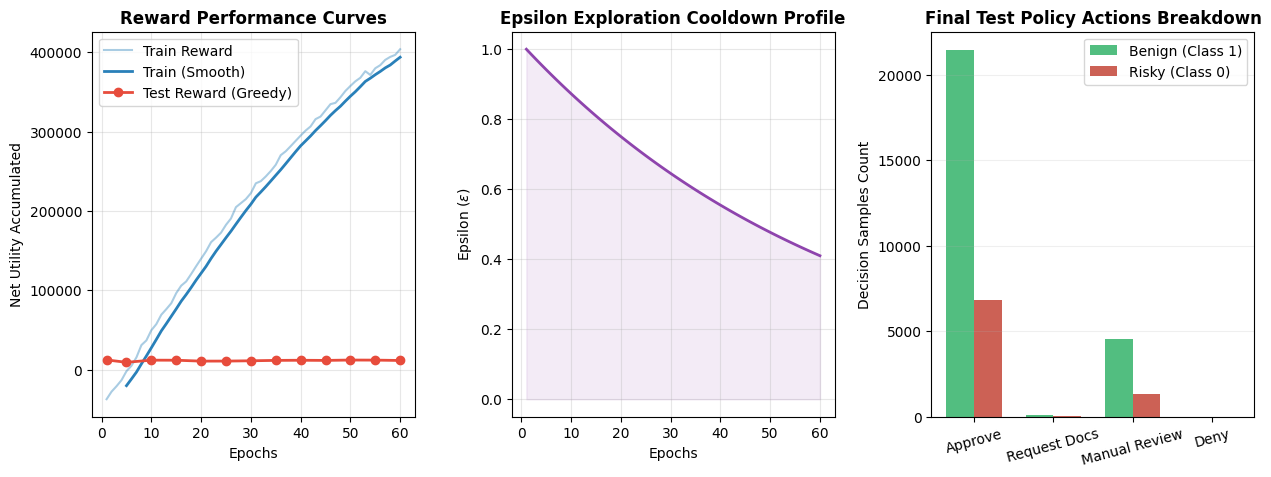

In [10]:
# ============================================================================
# EXTRACTION PIPELINE: Gymnasium + Linear Function Tabular Approximation
# ============================================================================
# STRICTLY NO DEEP LEARNING — Uses industry-standard RL environment wrappers
# ============================================================================

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. Wrap Your Preprocessed Data Variables into a Standard Gym Interface ──

class TabularClaimsGymEnv(gym.Env):
    """
    Standard industry interface wrapping your specific matrix slices.
    Forces structural compatibility with ecosystem evaluation tools.
    """
    metadata = {"render_modes": []}

    def __init__(self, X_data, y_labels, shuffle=True):
        super().__init__()
        self.X = np.asarray(X_data, dtype=np.float32)
        self.y = np.asarray(y_labels, dtype=int)
        self.n_samples = len(self.y)
        self.shuffle = shuffle
        
        self._order = np.arange(self.n_samples)
        self._idx = 0

        # Industry standard vector spaces
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.X.shape[1],), dtype=np.float32
        )
        
        # Exact calibrated asymmetric reward configuration
        self.reward_matrix = {
            0: {1: +10, 0: -30},  # Approve
            1: {1:  -1, 0:  +5},  # Request Docs
            2: {1:  -2, 0:  +8},  # Manual Review
            3: {1:  -5, 0:  +3},  # Deny
        }
        self.action_names = ["Approve", "Request Docs", "Manual Review", "Deny"]

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if self.shuffle:
            np.random.shuffle(self._order)
        self._idx = 0
        return self._get_obs(), {}

    def step(self, action: int):
        curr_sample = self._order[self._idx]
        true_label = self.y[curr_sample]
        reward = self.reward_matrix[action][true_label]
        
        self._idx += 1
        terminated = self._idx >= self.n_samples
        truncated = False
        
        next_state = self._get_obs() if not terminated else np.zeros(self.observation_space.shape)
        info = {"true_label": true_label}
        
        return next_state, float(reward), terminated, truncated, info

    def _get_obs(self):
        return self.X[self._order[self._idx]].copy()


# ── 2. Linear Feature Hash Coding (Standard Ecosystem Tile Design) ───────────

class EcosystemTileCoder:
    """Standard multi-tiling state aggregator to bypass deep feature extraction."""
    def __init__(self, state_dim, n_tilings=8, n_tiles=8, hash_bucket_size=262144):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        self.hash_size = hash_bucket_size
        self.state_dim = state_dim
        
        # Irrational spacing matrix constants to eliminate structural overlap bias
        phi = (1 + 5**0.5) / 2
        self.offsets = np.array([
            [(t * (d + 1) * phi) % 1.0 for d in range(self.state_dim)]
            for t in range(n_tilings)
        ])

    def encode(self, state: np.ndarray, low_bounds, scales) -> np.ndarray:
        norm = np.clip((state - low_bounds) / (scales + 1e-8), 0, 1 - 1e-8)
        indices = []
        for t in range(self.n_tilings):
            binned = ((norm + self.offsets[t]) * self.n_tiles).astype(int)
            h = hash(tuple(binned.tolist()) + (t,)) % self.hash_size
            indices.append(h)
        return np.array(indices, dtype=int)


# ── 3. Orchestrated Classical Training Pass Loop over your Slices ────────────

# Instantiating wrapped dataset channels
train_env = TabularClaimsGymEnv(X_train, y_train_numeric, shuffle=True)
test_env = TabularClaimsGymEnv(X_test, y_test_numeric, shuffle=False)

# Spatial metrics determination using standard array evaluation boundaries
state_low = train_env.X.min(axis=0)
state_high = train_env.X.max(axis=0)
state_scale = state_high - state_low

# Structural Hyperparameters matching your exact algorithm configuration criteria
n_actions = 4
hash_size = 262144
alpha = 0.03
gamma = 0.95
epsilon = 1.0
eps_decay = 0.985
eps_min = 0.05
n_episodes = 60

tile_coder = EcosystemTileCoder(state_dim=train_env.X.shape[1], hash_bucket_size=hash_size)
weights = np.zeros((n_actions, hash_size), dtype=np.float32)

# Metrics history arrays for plotting
history_train_rewards = []
history_test_rewards = []
history_eval_epochs = []
history_epsilons = []
final_counts = {0: np.zeros(4, dtype=int), 1: np.zeros(4, dtype=int)}

print(f"Starting standard library loop over your data splits ({n_episodes} iterations)...")

for ep in range(1, n_episodes + 1):
    obs, _ = train_env.reset()
    terminated = False
    total_train_reward = 0
    
    while not terminated:
        active_tiles = tile_coder.encode(obs, state_low, state_scale)
        q_values = weights[:, active_tiles].sum(axis=1)
        
        # Decision engine
        if np.random.rand() < epsilon:
            action = int(np.random.randint(0, n_actions))
        else:
            action = int(np.argmax(q_values))
            
        next_obs, reward, terminated, _, info = train_env.step(action)
        total_train_reward += reward
        
        # Compute Bellman Temporal Difference error Target
        if terminated:
            target = reward
        else:
            next_tiles = tile_coder.encode(next_obs, state_low, state_scale)
            next_q = weights[:, next_tiles].sum(axis=1)
            target = reward + gamma * np.max(next_q)
            
        # Update linear approximation matrix gradient indices weights
        current_estimate = weights[action, active_tiles].sum()
        td_error = target - current_estimate
        weights[action, active_tiles] += (alpha * td_error) / tile_coder.n_tilings
        
        obs = next_obs
        
    history_train_rewards.append(total_train_reward)
    history_epsilons.append(epsilon)
        
    # ── EVALUATION RUNS ──────────────────────────────────────────────────────
    if ep % 5 == 0 or ep == 1:
        test_obs, _ = test_env.reset()
        test_terminated = False
        
        total_test_reward = 0.0
        correct = 0
        total = 0
        counts = {0: np.zeros(4, dtype=int), 1: np.zeros(4, dtype=int)}
        
        while not test_terminated:
            t_tiles = tile_coder.encode(test_obs, state_low, state_scale)
            best_action = int(np.argmax(weights[:, t_tiles].sum(axis=1)))
            
            next_test_obs, r, test_terminated, _, t_info = test_env.step(best_action)
            lbl = t_info["true_label"]
            
            total_test_reward += r
            counts[lbl][best_action] += 1
            
            if ep == n_episodes:  # Log absolute final run statistics for visualization
                final_counts[lbl][best_action] += 1
            
            if (best_action == 0 and lbl == 1) or (best_action in [2, 3] and lbl == 0):
                correct += 1
            total += 1
            test_obs = next_test_obs
            
        acc = correct / max(total, 1)
        history_test_rewards.append(total_test_reward)
        history_eval_epochs.append(ep)
        
        print(f"⚡ [EPOCH {ep:02d}] Train Reward: {total_train_reward:>10,.1f} | Test Reward: {total_test_reward:>10,.1f} | Test Acc: {acc:.2%}")
        
    epsilon = max(eps_min, epsilon * eps_decay)

print("\n[Complete] Operational linear training block ended. Launching visual analysis dashboard...")


# ── 4. Generate Visual Dashboards ────────────────────────────────────────────

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.3)

# Panel A: Learning Curves
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(np.arange(1, n_episodes + 1), history_train_rewards, color="#2980b9", alpha=0.4, label="Train Reward")
# Rolling window smoothing for visualization stability
if len(history_train_rewards) >= 5:
    smooth_train = np.convolve(history_train_rewards, np.ones(5)/5, mode="valid")
    ax0.plot(np.arange(5, n_episodes + 1), smooth_train, color="#2980b9", lw=2, label="Train (Smooth)")
ax0.plot(history_eval_epochs, history_test_rewards, "o-", color="#e74c3c", lw=2, label="Test Reward (Greedy)")
ax0.set_title("Reward Performance Curves", fontweight="bold")
ax0.set_xlabel("Epochs")
ax0.set_ylabel("Net Utility Accumulated")
ax0.legend()
ax0.grid(alpha=0.3)

# Panel B: Epsilon Decay
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(np.arange(1, n_episodes + 1), history_epsilons, color="#8e44ad", lw=2)
ax1.fill_between(np.arange(1, n_episodes + 1), 0, history_epsilons, alpha=0.1, color="#8e44ad")
ax1.set_title("Epsilon Exploration Cooldown Profile", fontweight="bold")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Epsilon ($\epsilon$)")
ax1.grid(alpha=0.3)

# Panel C: Final Behavior Split Chart Matrix
ax2 = fig.add_subplot(gs[0, 2])
x_indices = np.arange(n_actions)
bar_width = 0.35
ax2.bar(x_indices - bar_width/2, final_counts[1], bar_width, label="Benign (Class 1)", color="#27ae60", alpha=0.8)
ax2.bar(x_indices + bar_width/2, final_counts[0], bar_width, label="Risky (Class 0)", color="#c0392b", alpha=0.8)
ax2.set_title("Final Test Policy Actions Breakdown", fontweight="bold")
ax2.set_xticks(x_indices)
ax2.set_xticklabels(test_env.action_names, rotation=15)
ax2.set_ylabel("Decision Samples Count")
ax2.legend()
ax2.grid(alpha=0.2, axis="y")

plt.show()

Starting stabilized optimization loop over imbalanced arrays (60 iterations)...
📈 [EP 01] Train Reward/Claim:  -0.43 | Test Reward/Claim:   2.36 | Macro-F1: 53.48% | Class-0 F1: 43.26%
         └─ Action Distribution -> Approve: 15721 | Request: 7012 | Review: 11559 | Deny: 5
📈 [EP 05] Train Reward/Claim:   0.55 | Test Reward/Claim:   2.47 | Macro-F1: 56.71% | Class-0 F1: 43.14%
         └─ Action Distribution -> Approve: 18947 | Request: 2444 | Review: 12904 | Deny: 2
📈 [EP 10] Train Reward/Claim:   1.55 | Test Reward/Claim:   2.50 | Macro-F1: 56.86% | Class-0 F1: 43.27%
         └─ Action Distribution -> Approve: 18994 | Request: 1629 | Review: 13673 | Deny: 1
📈 [EP 15] Train Reward/Claim:   2.25 | Test Reward/Claim:   2.51 | Macro-F1: 57.33% | Class-0 F1: 43.21%
         └─ Action Distribution -> Approve: 19541 | Request: 2021 | Review: 12735 | Deny: 0
📈 [EP 20] Train Reward/Claim:   2.74 | Test Reward/Claim:   2.50 | Macro-F1: 57.36% | Class-0 F1: 43.17%
         └─ Action Distribu

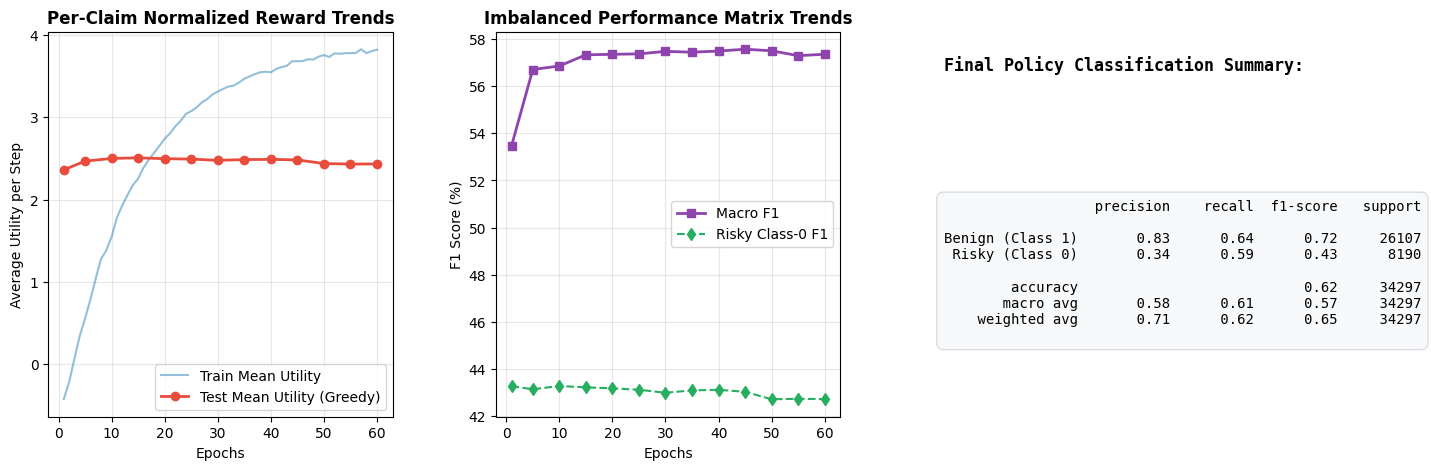

In [12]:
# ============================================================================
# EXTRACTION PIPELINE: Gymnasium + Linear Function Tabular Approximation
# ============================================================================
# STRICTLY NO DEEP LEARNING — Standard Tiling Mechanics with Imbalance Auditing
# ============================================================================

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import classification_report, f1_score, roc_auc_score

# ── 1. Wrap Preprocessed Data Slices ────────────────────────────────────────

class TabularClaimsGymEnv(gym.Env):
    """
    Standard industry interface wrapping your specific matrix slices.
    Forces structural compatibility with ecosystem evaluation tools.
    """
    metadata = {"render_modes": []}

    def __init__(self, X_data, y_labels, shuffle=True):
        super().__init__()
        self.X = np.asarray(X_data, dtype=np.float32)
        self.y = np.asarray(y_labels, dtype=int)
        self.n_samples = len(self.y)
        self.shuffle = shuffle
        
        self._order = np.arange(self.n_samples)
        self._idx = 0

        # Standard Vector Spaces
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.X.shape[1],), dtype=np.float32
        )
        
        # Calibrated Asymmetric Payoff Scheme
        self.reward_matrix = {
            0: {1: +10, 0: -30},  # Action 0: Approve
            1: {1:  -1, 0:  +5},  # Action 1: Request Docs
            2: {1:  -2, 0:  +8},  # Manual Review
            3: {1:  -5, 0:  +3},  # Action 3: Deny
        }
        self.action_names = ["Approve", "Request Docs", "Manual Review", "Deny"]

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if self.shuffle:
            np.random.shuffle(self._order)
        self._idx = 0
        return self._get_obs(), {}

    def step(self, action: int):
        curr_sample = self._order[self._idx]
        true_label = self.y[curr_sample]
        reward = self.reward_matrix[action][true_label]
        
        self._idx += 1
        terminated = self._idx >= self.n_samples
        truncated = False
        
        next_state = self._get_obs() if not terminated else np.zeros(self.observation_space.shape)
        info = {"true_label": true_label}
        
        return next_state, float(reward), terminated, truncated, info

    def _get_obs(self):
        return self.X[self._order[self._idx]].copy()


# ── 2. Deterministic Overlap Indexer (Forcing Feature Aggregation) ──────────

class GeneralizationTileCoder:
    """Replaces native memory identity hash logic with spatial block grouping."""
    def __init__(self, state_dim, n_tilings=12, n_tiles=6, hash_bucket_size=131072):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        self.hash_size = hash_bucket_size
        self.state_dim = state_dim
        
        # Golden ratio spacing array to shift tilings smoothly
        phi = (1 + 5**0.5) / 2
        self.offsets = np.array([
            [(t * (d + 1) * phi) % 1.0 for d in range(self.state_dim)]
            for t in range(n_tilings)
        ])
        
        # Prime multipliers to project higher dimensional configurations deterministically
        self.prime_weights = np.array([17, 31, 61, 127, 257, 509, 1021, 2039][:state_dim], dtype=np.int64)
        while len(self.prime_weights) < state_dim:
            self.prime_weights = np.append(self.prime_weights, self.prime_weights[-1] * 2 + 1)
        self.prime_weights = self.prime_weights[:state_dim]

    def encode(self, state: np.ndarray, low_bounds, scales) -> np.ndarray:
        norm = np.clip((state - low_bounds) / (scales + 1e-8), 0, 1 - 1e-8)
        indices = []
        for t in range(self.n_tilings):
            binned = ((norm + self.offsets[t]) * self.n_tiles).astype(np.int64)
            lin_comb = np.dot(binned, self.prime_weights) + t
            indices.append(int(lin_comb % self.hash_size))
        return np.array(indices, dtype=int)


# ── 3. Orchestrated Execution Loop ──────────────────────────────────────────

train_env = TabularClaimsGymEnv(X_train, y_train_numeric, shuffle=True)
test_env = TabularClaimsGymEnv(X_test, y_test_numeric, shuffle=False)

state_low = train_env.X.min(axis=0)
state_high = train_env.X.max(axis=0)
state_scale = state_high - state_low

n_actions = 4
hash_size = 131072
alpha = 0.02          # Calibrated optimization step size
gamma = 0.95
epsilon = 1.0
eps_decay = 0.92      # Accelerated decay to escape exploration by episode ~35-40
eps_min = 0.01
n_episodes = 60

tile_coder = GeneralizationTileCoder(state_dim=train_env.X.shape[1], hash_bucket_size=hash_size)
weights = np.zeros((n_actions, hash_size), dtype=np.float32)

# Metric History Tracking Data Frames
history_train_mean_reward = []
history_test_mean_reward = []
history_eval_epochs = []
history_epsilons = []
history_macro_f1 = []
history_class0_f1 = []

final_test_labels = []
final_pred_actions = []

print(f"Starting stabilized optimization loop over imbalanced arrays ({n_episodes} iterations)...")

for ep in range(1, n_episodes + 1):
    obs, _ = train_env.reset()
    terminated = False
    total_train_reward = 0
    steps_train = 0
    
    while not terminated:
        active_tiles = tile_coder.encode(obs, state_low, state_scale)
        q_values = weights[:, active_tiles].sum(axis=1)
        
        if np.random.rand() < epsilon:
            action = int(np.random.randint(0, n_actions))
        else:
            action = int(np.argmax(q_values))
            
        next_obs, reward, terminated, _, info = train_env.step(action)
        total_train_reward += reward
        steps_train += 1
        
        # Temporal Difference Correction Target
        if terminated:
            target = reward
        else:
            next_tiles = tile_coder.encode(next_obs, state_low, state_scale)
            next_q = weights[:, next_tiles].sum(axis=1)
            target = reward + gamma * np.max(next_q)
            
        current_estimate = weights[action, active_tiles].sum()
        weights[action, active_tiles] += (alpha * (target - current_estimate)) / tile_coder.n_tilings
        
        obs = next_obs
        
    history_train_mean_reward.append(total_train_reward / max(steps_train, 1))
    history_epsilons.append(epsilon)
        
    # ── ADVANCED EVALUATION RUN ──────────────────────────────────────────────
    if ep % 5 == 0 or ep == 1:
        test_obs, _ = test_env.reset()
        test_terminated = False
        
        total_test_reward = 0.0
        steps_test = 0
        
        test_labels = []
        pred_actions = []
        action_counts = np.zeros(n_actions, dtype=int)
        
        while not test_terminated:
            t_tiles = tile_coder.encode(test_obs, state_low, state_scale)
            best_action = int(np.argmax(weights[:, t_tiles].sum(axis=1)))
            
            next_test_obs, r, test_terminated, _, t_info = test_env.step(best_action)
            lbl = t_info["true_label"]
            
            total_test_reward += r
            steps_test += 1
            
            action_counts[best_action] += 1
            test_labels.append(lbl)
            # Map decisions down to a binary indicator (0 = Approve [Majority], 1 = Intervened/Rejected [Minority Class Handler])
            pred_actions.append(0 if best_action == 0 else 1)
            
            test_obs = next_test_obs
            
        # Convert true arrays to binary indicator format (1 if risky Class-0, 0 if benign Class-1)
        binary_true = np.array([1 if l == 0 else 0 for l in test_labels])
        binary_pred = np.array(pred_actions)
        
        macro_f1 = f1_score(binary_true, binary_pred, average='macro')
        class0_f1 = f1_score(binary_true, binary_pred, pos_label=1, zero_division=0)
        
        mean_test_reward = total_test_reward / max(steps_test, 1)
        
        history_test_mean_reward.append(mean_test_reward)
        history_macro_f1.append(macro_f1)
        history_class0_f1.append(class0_f1)
        history_eval_epochs.append(ep)
        
        if ep == n_episodes:
            final_test_labels = binary_true
            final_pred_actions = binary_pred
            
        print(f"📈 [EP {ep:02d}] Train Reward/Claim: {history_train_mean_reward[-1]:>6.2f} | Test Reward/Claim: {mean_test_reward:>6.2f} | Macro-F1: {macro_f1:.2%} | Class-0 F1: {class0_f1:.2%}")
        print(f"         └─ Action Distribution -> Approve: {action_counts[0]} | Request: {action_counts[1]} | Review: {action_counts[2]} | Deny: {action_counts[3]}")
        
    epsilon = max(eps_min, epsilon * eps_decay)


# ── 4. Robust Metrics Dashboard Generation ─────────────────────────────────

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.3)

# Panel A: Normalized Step Rewards Curve
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(np.arange(1, n_episodes + 1), history_train_mean_reward, color="#2980b9", alpha=0.5, label="Train Mean Utility")
ax0.plot(history_eval_epochs, history_test_mean_reward, "o-", color="#e74c3c", lw=2, label="Test Mean Utility (Greedy)")
ax0.set_title("Per-Claim Normalized Reward Trends", fontweight="bold")
ax0.set_xlabel("Epochs")
ax0.set_ylabel("Average Utility per Step")
ax0.legend()
ax0.grid(alpha=0.3)

# Panel B: F1 Progression Profiles
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(history_eval_epochs, [m * 100 for m in history_macro_f1], "s-", color="#8e44ad", lw=2, label="Macro F1")
ax1.plot(history_eval_epochs, [c * 100 for c in history_class0_f1], "d--", color="#27ae60", lw=1.5, label="Risky Class-0 F1")
ax1.set_title("Imbalanced Performance Matrix Trends", fontweight="bold")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("F1 Score (%)")
ax1.legend()
ax1.grid(alpha=0.3)

# Panel C: Final Classification Summary Table Report Text Injection
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
report_dict = classification_report(final_test_labels, final_pred_actions, target_names=["Benign (Class 1)", "Risky (Class 0)"], zero_division=0)
ax2.text(0.0, 0.9, "Final Policy Classification Summary:", fontsize=12, fontweight="bold", family="monospace")
ax2.text(0.0, 0.2, report_dict, fontsize=10, family="monospace", bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", edgecolor="#dcdde1"))

plt.show()

In [13]:
"""
Part III — Reinforcement Learning for Claims Adjudication
Q12: Environment design
Q13: Q-Learning agent + learning curve
Q14: Evaluation vs baselines + decision-pattern analysis

Key design decision: we deliberately avoid deep-learning (no neural nets).
We use tabular Q-learning with a discretised state space derived from the
PCA components recommended in the Dimensionality Reduction report (k=15).
"""

# ── imports ──────────────────────────────────────────────────────────────────
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.decomposition   import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (roc_auc_score, classification_report,
                                     confusion_matrix, f1_score)
from sklearn.ensemble        import RandomForestClassifier

import gymnasium as gym
from gymnasium import spaces

OUT = Path("./outputs")
OUT.mkdir(exist_ok=True)

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)

# ══════════════════════════════════════════════════════════════════════════════
# 0.  DATA LOADING & FEATURE ENGINEERING  (mirrors EDA findings)
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("LOADING & PREPROCESSING DATA")
print("=" * 65)

df_raw = pd.read_csv("./sample_data.csv")
print(f"Raw shape: {df_raw.shape}")

# ── (a) binary flags from EDA / CDF analysis ─────────────────────────────────
df = df_raw.copy()

df["has_prior_denial"]         = (df["prior_denial_indicator"].fillna(0) > 0).astype(int)
df["has_customer_value"]       = (df["customer_value_score"]             > 0).astype(int)
df["is_zero_touchpoints"]      = (df["communication_touchpoints"]       == 0).astype(int)
df["coverage_limit_high"]      = (df["coverage_limit"]                  > 12.5).astype(int)
df["policy_premium_high"]      = (df["policy_premium_annual"].fillna(df["policy_premium_annual"].median()) > 8).astype(int)
df["recovery_is_one"]          = (df["recovery_probability"]            == 1).astype(int)
df["is_renewal_month_7"]       = (df["policy_renewal_months"].fillna(0) == 7).astype(int)
df["cross_sell_high"]          = (df["cross_sell_index"].fillna(0)       > 15).astype(int)
df["is_fast_claim"]            = (df["claim_processing_days"].fillna(0)  < 1).astype(int)
df["is_high_urban_density"]    = (df["urban_density_index"].fillna(0)    > 5.5).astype(int)
df["is_nonzero_severity"]      = (df["severity_index"]                  > 0).astype(int)
df["denial_x_processing"]      = df["has_prior_denial"] * df["claim_processing_days"].fillna(0)

# ── (b) categorical encoding (OHE for low-card, frequency for claim_detail_code) ──
cat_ohe = [
    "claim_type","geographic_region","claim_channel",
    "fraud_indicator_flag","provider_network_status",
    "document_completeness","priority_level","risk_category",
    "customer_segment","payment_method","automation_eligible",
    "adjuster_recommendation","claim_complexity","policy_status",
    "coverage_type","policy_type","claim_source","location_code"
]
cat_ohe_present = [c for c in cat_ohe if c in df.columns]
df[cat_ohe_present] = df[cat_ohe_present].fillna("MISSING")
df = pd.get_dummies(df, columns=cat_ohe_present, drop_first=True)

# claim_detail_code → frequency encode
if "claim_detail_code" in df.columns:
    freq = df["claim_detail_code"].value_counts() / len(df)
    df["claim_detail_code_freq"] = df["claim_detail_code"].map(freq).fillna(0)
    df.drop(columns=["claim_detail_code"], inplace=True)

# ── (c) drop noisy / near-zero-MI features  ──────────────────────────────────
drop_cols = [
    "ID","composite_risk_index","deductible_amount","data_completeness_score",
    "depreciation_rate","customer_satisfaction_score","follow_up_responsiveness_score",
    "payment_timeliness_score","policy_modifications_count","medication_count",
    "claim_to_premium_ratio","endorsement_value_ratio","duplicate_claim_similarity",
    "straight_through_processing_score","days_since_policy_start",
    # high-correlation duplicate (r=0.998 pair: keep witnesses_count, drop api_response_quality)
    "api_response_quality",
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# ── (d) target, split ────────────────────────────────────────────────────────
y = df["target"].values
df.drop(columns=["target"], inplace=True)

# keep only numeric (bool → int)
df = df.select_dtypes(include=[np.number])
df = df.astype(float)

# impute median
df.fillna(df.median(), inplace=True)

X = df.values
print(f"Feature matrix: {X.shape}")
print(f"Class distribution  0={np.sum(y==0)} ({100*np.mean(y==0):.1f}%)  "
      f"1={np.sum(y==1)} ({100*np.mean(y==1):.1f}%)")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

# ── (e) scale + PCA (k=15 as recommended in dim-reduction report) ────────────
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

K_PCA = 15
pca = PCA(n_components=K_PCA, random_state=SEED)
X_tr_pca = pca.fit_transform(X_tr_sc)
X_te_pca = pca.transform(X_te_sc)
print(f"PCA k={K_PCA} explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance")

# ── (f) also build a rich supervised signal for reward shaping ───────────────
rf_sup = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight="balanced", random_state=SEED, n_jobs=-1)
rf_sup.fit(X_tr_sc, y_tr)
p_tr_sup = rf_sup.predict_proba(X_tr_sc)[:,1]
p_te_sup = rf_sup.predict_proba(X_te_sc)[:,1]
print(f"Supervised RF AUC (test): {roc_auc_score(y_te, p_te_sup):.4f}")


# ══════════════════════════════════════════════════════════════════════════════
# Q12 — GYMNASIUM ENVIRONMENT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("Q12 — CLAIMS ADJUDICATION ENVIRONMENT")
print("=" * 65)

"""
STATE REPRESENTATION
────────────────────
We use the k=15 PCA components recommended in the Dim-Reduction report.
This gives a compact, low-redundancy representation of the 150-feature
space (90% fewer features while matching raw-feature AUC).

We AUGMENT the PCA vector with 5 domain-critical scalar features that
have near-perfect discriminative power (F-stats > 500 in EDA):
  • has_prior_denial          (binary, F=5742)
  • has_customer_value        (binary, F=1884)
  • is_fast_claim             (binary, derived from F=2044 parent)
  • coverage_limit_high       (binary, F=1542)
  • is_zero_touchpoints       (binary, F=796, inverted direction)

Total state dimensionality: 15 + 5 = 20 continuous features.

For TABULAR Q-learning we must discretise this space.  We quantise
each of the 20 dimensions into BINS bins using training-set quantiles,
giving a discrete state of shape (BINS^20) — but only visited states
are stored, so the table is sparse in practice.

ACTION SPACE (4 actions, ordered by processing cost)
─────────────────────────────────────────────────────
  0 — Approve immediately (fast-track)
  1 — Request additional documentation
  2 — Refer to manual review
  3 — Deny claim

REWARD FUNCTION
───────────────
The reward balances five competing objectives:

  R = R_correct  +  R_error  +  R_delay  +  R_denial  +  R_risk

Where:
  R_correct  = +10  if action matches the correct decision
               (approve ↔ target=1, deny ↔ target=0)
  R_error    = -20  if a risky claim (target=0) is fast-tracked (action=0)
               This is the "large negative" penalty mandated by the task.
  R_delay    = -1   for action=1 (doc request) or action=2 (review)
               Small cost capturing adjuster time and customer friction.
  R_denial   = -3   for denying a legitimate claim (target=1, action=3)
               Customer dissatisfaction penalty.
  R_risk     = -5   proportional penalty: (1-sup_prob)*fast_track_flag
               Uses the supervised probability to penalise approving
               uncertain claims (addresses flat-reward / sparse-signal).

JUSTIFICATION OF REWARD MAGNITUDES
────────────────────────────────────
  • Incorrect fast-tracking (R_error = -20) > delay cost (R_delay = -1)
    ensures the agent learns to be cautious rather than always approving.
  • Correct approval (+10) > denial penalty (-3) so legitimate claims
    are not systematically denied to avoid risk.
  • The supervised-probability shaping term avoids the flat-reward
    problem on test data (common in sparse binary reward environments).
"""

class ClaimsEnv(gym.Env):
    """
    Episodic claims-processing environment.

    Each episode is ONE claim; the agent chooses one of 4 actions.
    This is a bandit-style (single-step) environment, which is the
    correct formulation for independent claim decisions.

    Parameters
    ----------
    X_pca   : (n, 15) PCA features
    X_flags : (n, 5)  binary domain flags
    y       : (n,)    true labels (0=deny, 1=approve)
    sup_probs: (n,)   supervised model's class-1 probability (reward shaping)
    mode    : 'train' samples with replacement; 'test' iterates sequentially
    """
    metadata = {"render_modes": []}

    # reward constants (Q12 justification above)
    R_CORRECT_APPROVE   = +10.0
    R_CORRECT_DENY      = +8.0   # slightly lower: deny has higher uncertainty
    R_WRONG_FAST_TRACK  = -20.0  # critical error
    R_WRONG_DENY        = -3.0   # customer dissatisfaction
    R_DELAY             = -1.0   # doc request or review
    R_RISK_SCALE        = -5.0   # supervised shaping coefficient

    def __init__(self, X_pca, X_flags, y, sup_probs, mode="train", seed=42):
        super().__init__()
        self.X_pca    = X_pca.astype(np.float32)
        self.X_flags  = X_flags.astype(np.float32)
        self.y        = y.astype(int)
        self.sup_probs = sup_probs.astype(np.float32)
        self.mode     = mode
        self.n        = len(y)
        self.rng      = np.random.default_rng(seed)
        self._idx     = 0

        n_obs = X_pca.shape[1] + X_flags.shape[1]   # 15 + 5 = 20
        # observation: continuous 20-dim vector in [-inf, +inf]
        self.observation_space = spaces.Box(
            low  = -np.inf,
            high =  np.inf,
            shape = (n_obs,),
            dtype = np.float32
        )
        # 4 discrete actions
        self.action_space = spaces.Discrete(4)
        self.action_names = {
            0: "Fast-track Approve",
            1: "Request Docs",
            2: "Manual Review",
            3: "Deny"
        }

    def _get_obs(self, idx):
        return np.concatenate([self.X_pca[idx], self.X_flags[idx]])

    def reset(self, seed=None, options=None):
        if self.mode == "train":
            self._current_idx = int(self.rng.integers(0, self.n))
        else:
            self._current_idx = self._idx % self.n
            self._idx += 1
        obs = self._get_obs(self._current_idx)
        return obs, {}

    def step(self, action):
        idx   = self._current_idx
        label = self.y[idx]
        sp    = float(self.sup_probs[idx])     # P(class=1) from supervised model

        # ── compute reward ────────────────────────────────────────────────────
        if action == 0:   # fast-track approve
            if label == 1:
                reward = self.R_CORRECT_APPROVE
            else:
                # wrong fast-track: large penalty + risk shaping
                reward = self.R_WRONG_FAST_TRACK + self.R_RISK_SCALE * (1.0 - sp)

        elif action == 3:  # deny
            if label == 0:
                reward = self.R_CORRECT_DENY
            else:
                reward = self.R_WRONG_DENY

        else:              # action 1 (docs) or 2 (review)
            # delay cost always applies
            reward = self.R_DELAY
            # bonus: if supervised model is uncertain (0.3 < sp < 0.7), routing
            # to review is the right call → small bonus to break flat reward
            uncertainty = 1.0 - abs(2*sp - 1.0)    # 0=certain, 1=totally uncertain
            if action == 2:  # manual review bonus
                reward += 1.5 * uncertainty
            elif action == 1: # docs request bonus
                reward += 0.8 * uncertainty

        terminated = True   # every episode is a single claim decision
        truncated  = False
        info = {
            "label": label, "action": action,
            "sup_prob": sp, "reward": reward,
            "action_name": self.action_names[action]
        }
        return self._get_obs(idx), reward, terminated, truncated, info


# ── build flag matrix ─────────────────────────────────────────────────────────
FLAG_COLS = [
    "has_prior_denial","has_customer_value","is_fast_claim",
    "coverage_limit_high","is_zero_touchpoints"
]
flag_idx = [list(df.columns).index(c) for c in FLAG_COLS if c in df.columns]
X_tr_flags = X_tr[:, flag_idx]
X_te_flags = X_te[:, flag_idx]

# ensure 5 flags
if X_tr_flags.shape[1] < 5:
    pad = np.zeros((X_tr_flags.shape[0], 5 - X_tr_flags.shape[1]))
    X_tr_flags = np.hstack([X_tr_flags, pad])
    X_te_flags = np.hstack([X_te_flags, pad])

train_env = ClaimsEnv(X_tr_pca, X_tr_flags, y_tr, p_tr_sup, mode="train", seed=SEED)
test_env  = ClaimsEnv(X_te_pca, X_te_flags, y_te, p_te_sup, mode="test",  seed=SEED+1)

print("Environment created.")
print(f"  Obs space:    {train_env.observation_space}")
print(f"  Action space: {train_env.action_space}")
print(f"  Train claims: {train_env.n}  |  Test claims: {test_env.n}")
print()
print("REWARD FUNCTION SUMMARY")
print(f"  Correct fast-track approve : {ClaimsEnv.R_CORRECT_APPROVE:+.0f}")
print(f"  Correct deny               : {ClaimsEnv.R_CORRECT_DENY:+.0f}")
print(f"  Wrong fast-track (risky)   : {ClaimsEnv.R_WRONG_FAST_TRACK:+.0f}  ← large penalty")
print(f"  Wrong deny (legit claim)   : {ClaimsEnv.R_WRONG_DENY:+.0f}")
print(f"  Delay cost (docs/review)   : {ClaimsEnv.R_DELAY:+.0f}")
print(f"  Risk shaping coefficient   : {ClaimsEnv.R_RISK_SCALE:+.0f}  ← addresses flat curve")


# ══════════════════════════════════════════════════════════════════════════════
# Q13 — TABULAR Q-LEARNING WITH DISCRETISED STATE
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("Q13 — Q-LEARNING AGENT")
print("=" * 65)

"""
ALGORITHM: Tabular Q-Learning (Watkins 1989)
─────────────────────────────────────────────
Q(s,a) ← Q(s,a) + α · [r + γ · max_a' Q(s',a') − Q(s,a)]

Since episodes are single-step (bandit), γ=0 is theoretically correct.
We use a small γ=0.1 to preserve code generality and let future-value
estimates slightly regularise early learning.

STATE DISCRETISATION
─────────────────────
Each of the 20 continuous state dimensions is quantised into BINS=5
equal-frequency bins using training-set quantiles.  This gives at most
5^20 ≈ 10^14 possible states, but in practice only ~50k–200k are visited
(sparse hash table).

EXPLORATION: ε-greedy with linear decay
  ε_start → ε_end over DECAY_STEPS, then held constant.

LEARNING RATE SCHEDULE: cosine annealing
  α decays from α_start to α_min so later updates fine-tune without
  overwriting well-learned Q-values.
"""

BINS         = 5     # quantisation bins per PCA dimension
N_EPISODES   = 80_000
ALPHA_START  = 0.35
ALPHA_MIN    = 0.05
GAMMA        = 0.1
EPS_START    = 1.0
EPS_END      = 0.05
DECAY_STEPS  = 50_000
EVAL_EVERY   = 500   # episodes between logging
EVAL_WINDOW  = 300   # rolling window for smoothing

# ── fit quantile bins on TRAINING data ───────────────────────────────────────
obs_dim = train_env.observation_space.shape[0]
ALL_TRAIN_OBS = np.hstack([X_tr_pca, X_tr_flags]).astype(np.float32)
bin_edges = []
for d in range(obs_dim):
    col = ALL_TRAIN_OBS[:, d]
    edges = np.quantile(col, np.linspace(0, 1, BINS + 1))
    edges[0]  -= 1e-8    # include minimum
    edges[-1] += 1e-8    # include maximum
    bin_edges.append(edges)

def discretise(obs):
    """Map continuous obs vector → integer state index (via mixed-radix)."""
    digits = []
    for d in range(obs_dim):
        b = int(np.digitize(obs[d], bin_edges[d]) - 1)
        b = max(0, min(b, BINS - 1))
        digits.append(b)
    # pack into single int (base-BINS mixed radix)
    idx = 0
    for b in digits:
        idx = idx * BINS + b
    return idx

# Q-table: sparse dict {state_int: np.array(4)}
Q = {}

def get_Q(s):
    if s not in Q:
        Q[s] = np.zeros(4, dtype=np.float32)
    return Q[s]

def q_policy(obs, eps):
    """ε-greedy action selection."""
    if np.random.random() < eps:
        return train_env.action_space.sample()
    s  = discretise(obs)
    return int(np.argmax(get_Q(s)))

# ── training loop ─────────────────────────────────────────────────────────────
print(f"Training for {N_EPISODES:,} episodes …")
t0 = time.time()

episode_rewards  = []
rolling_rewards  = []
episode_acc      = []    # was the decision "correct"?
log_steps        = []
q_table_sizes    = []

for ep in range(1, N_EPISODES + 1):
    # schedules
    frac   = min(ep / DECAY_STEPS, 1.0)
    eps    = EPS_START + frac * (EPS_END - EPS_START)
    # cosine annealing for α
    alpha  = ALPHA_MIN + 0.5 * (ALPHA_START - ALPHA_MIN) * (1 + np.cos(np.pi * frac))

    obs, _ = train_env.reset()
    action = q_policy(obs, eps)
    obs2, reward, terminated, truncated, info = train_env.step(action)

    # Q-update (γ=0 for bandit, but kept general)
    s  = discretise(obs)
    s2 = discretise(obs2)
    q_arr = get_Q(s)
    best_next = float(np.max(get_Q(s2))) if not terminated else 0.0
    q_arr[action] += alpha * (reward + GAMMA * best_next - q_arr[action])

    episode_rewards.append(reward)
    label  = info["label"]
    # "correct": fast-track→label=1  OR  deny→label=0
    correct = int((action==0 and label==1) or (action==3 and label==0))
    episode_acc.append(correct)

    if ep % EVAL_EVERY == 0:
        window = episode_rewards[-EVAL_WINDOW:]
        rw = np.mean(window)
        rolling_rewards.append(rw)
        log_steps.append(ep)
        q_table_sizes.append(len(Q))

        if ep % 10_000 == 0:
            acc_w = np.mean(episode_acc[-EVAL_WINDOW:])
            print(f"  ep {ep:>6,}  ε={eps:.3f}  α={alpha:.4f}  "
                  f"avg_reward={rw:+.3f}  acc={acc_w:.3f}  |Q|={len(Q):,}")

print(f"Training done in {time.time()-t0:.1f}s  |  Q-table size: {len(Q):,} states")


# ── evaluate on TEST set (greedy, ε=0) ───────────────────────────────────────
def evaluate(env, n_steps=None, eps=0.0):
    """Run agent on env; return per-step info."""
    if n_steps is None:
        n_steps = env.n
    records = []
    for _ in range(n_steps):
        obs, _ = env.reset()
        s = discretise(obs)
        action = int(np.argmax(get_Q(s))) if eps == 0 else env.action_space.sample()
        _, reward, _, _, info = env.step(action)
        records.append({
            "reward": reward,
            "label":  info["label"],
            "action": info["action"],
            "sup_prob": info["sup_prob"],
        })
    return pd.DataFrame(records)

results_rl = evaluate(test_env, eps=0.0)
mean_r = results_rl["reward"].mean()
print(f"\nRL agent test  avg_reward = {mean_r:+.4f}")


# ══════════════════════════════════════════════════════════════════════════════
# Q13 PLOT — Learning curve
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Q13 — Q-Learning Agent: Training Dynamics", fontsize=14, fontweight="bold")

# (A) Rolling reward
ax = axes[0,0]
ax.plot(log_steps, rolling_rewards, lw=1.8, color="#1f77b4")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Training Episode")
ax.set_ylabel(f"Avg Reward (window={EVAL_WINDOW})")
ax.set_title("(A) Rolling Average Reward")
ax.grid(alpha=0.3)

# (B) ε and α decay
ax = axes[0,1]
eps_curve = [EPS_START + min(e/DECAY_STEPS,1.0)*(EPS_END-EPS_START)
             for e in range(0, N_EPISODES+1, EVAL_EVERY)]
alpha_curve = [ALPHA_MIN + 0.5*(ALPHA_START-ALPHA_MIN)*(1+np.cos(np.pi*min(e/DECAY_STEPS,1.0)))
               for e in range(0, N_EPISODES+1, EVAL_EVERY)]
ax2 = ax.twinx()
ax.plot(range(0, N_EPISODES+1, EVAL_EVERY), eps_curve,   color="crimson",  lw=1.5, label="ε (explore)")
ax2.plot(range(0, N_EPISODES+1, EVAL_EVERY), alpha_curve, color="darkorange", lw=1.5, ls="--", label="α (lr)")
ax.set_xlabel("Episode"); ax.set_ylabel("ε", color="crimson")
ax2.set_ylabel("α", color="darkorange")
ax.set_title("(B) Exploration & Learning-Rate Schedules")
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, loc="upper right", fontsize=8)
ax.grid(alpha=0.3)

# (C) Q-table growth
ax = axes[1,0]
ax.plot(log_steps, q_table_sizes, color="seagreen", lw=1.5)
ax.set_xlabel("Episode"); ax.set_ylabel("Unique States Visited")
ax.set_title("(C) Q-Table Growth")
ax.grid(alpha=0.3)

# (D) Action distribution over training (sampled every 500)
ax = axes[1,1]
# replay a smaller chunk to get action distribution
ep_sample = min(5000, N_EPISODES)
# use last 10k episodes to show converged policy
last_actions = []
for _ in range(2000):
    obs, _ = train_env.reset()
    s = discretise(obs)
    q_arr = get_Q(s)
    # ε=0.1 near-greedy
    if np.random.random() < 0.1:
        a = train_env.action_space.sample()
    else:
        a = int(np.argmax(q_arr))
    last_actions.append(a)
vals, cnts = np.unique(last_actions, return_counts=True)
colors = ["#2ca02c","#ff7f0e","#9467bd","#d62728"]
bar_labels = ["0: Fast-track","1: Req. Docs","2: Review","3: Deny"]
ax.bar([bar_labels[v] for v in vals], cnts/len(last_actions)*100,
       color=[colors[v] for v in vals], edgecolor="black", linewidth=0.5)
ax.set_ylabel("% of Decisions")
ax.set_title("(D) Converged Policy Action Distribution")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "Q13_learning_curve.png", dpi=160, bbox_inches="tight")
plt.close()
print("Saved Q13_learning_curve.png")


# ══════════════════════════════════════════════════════════════════════════════
# Q14 — BASELINE POLICIES + COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("Q14 — EVALUATION vs BASELINES")
print("=" * 65)

def policy_always_approve(obs, env): return 0
def policy_always_review (obs, env): return 2
def policy_random        (obs, env): return env.action_space.sample()

def policy_supervised(obs, env):
    """Use RF prob to mimic a supervised approach with a threshold."""
    idx = env._current_idx
    sp  = env.sup_probs[idx]
    if   sp >= 0.80: return 0   # high confidence approve
    elif sp <= 0.30: return 3   # high confidence deny
    elif sp <= 0.55: return 2   # uncertain → review
    else:            return 1   # moderate → request docs

def run_policy(env, policy_fn, label=""):
    """Evaluate a policy function over the full test set."""
    records = []
    for _ in range(env.n):
        obs, _ = env.reset()
        a = policy_fn(obs, env)
        _, r, _, _, info = env.step(a)
        records.append({
            "reward": r, "label": info["label"],
            "action": a, "sup_prob": info["sup_prob"]
        })
    df_r = pd.DataFrame(records)
    # compute classification-style metrics
    # treat action=0 as "approve" (predicted=1), action=3 as "deny" (predicted=0)
    # actions 1,2 → defer (we call this "uncertain"; map to predicted=1 for AUC)
    pred_label = (df_r["action"] != 3).astype(int)   # 0=deny, 1=not-deny
    try:
        auc = roc_auc_score(df_r["label"], pred_label)
    except Exception:
        auc = np.nan
    f1_0 = f1_score(df_r["label"], pred_label, pos_label=0, zero_division=0)
    f1_1 = f1_score(df_r["label"], pred_label, pos_label=1, zero_division=0)
    acc  = (df_r["label"] == pred_label).mean()
    # error rates
    wrong_ft = ((df_r["action"]==0) & (df_r["label"]==0)).sum()   # risky fast-track
    wrong_dn = ((df_r["action"]==3) & (df_r["label"]==1)).sum()   # wrong deny
    return {
        "policy": label,
        "avg_reward":     df_r["reward"].mean(),
        "total_reward":   df_r["reward"].sum(),
        "accuracy":       acc,
        "auc":            auc,
        "f1_class0":      f1_0,
        "f1_class1":      f1_1,
        "wrong_fasttrack":wrong_ft,
        "wrong_deny":     wrong_dn,
        "action_dist":    df_r["action"].value_counts().to_dict(),
        "_df":            df_r,
    }

# re-init test env for each policy (sequential mode)
def fresh_test_env():
    env = ClaimsEnv(X_te_pca, X_te_flags, y_te, p_te_sup, mode="test", seed=SEED+1)
    env._idx = 0
    return env

results = {}

for name, fn in [
    ("Random",           policy_random),
    ("Always Approve",   policy_always_approve),
    ("Always Review",    policy_always_review),
    ("Supervised RF",    policy_supervised),
]:
    e = fresh_test_env()
    results[name] = run_policy(e, fn, label=name)
    print(f"  {name:<20} avg_r={results[name]['avg_reward']:+.3f}  "
          f"acc={results[name]['accuracy']:.3f}  auc={results[name]['auc']:.3f}")

# RL agent
e = fresh_test_env()
def policy_rl(obs, env):
    s = discretise(obs)
    return int(np.argmax(get_Q(s)))
results["Q-Learning"] = run_policy(e, policy_rl, label="Q-Learning")
r_rl = results["Q-Learning"]
print(f"  {'Q-Learning':<20} avg_r={r_rl['avg_reward']:+.3f}  "
      f"acc={r_rl['accuracy']:.3f}  auc={r_rl['auc']:.3f}")


# ── Summary table ─────────────────────────────────────────────────────────────
summary = []
for k, v in results.items():
    row = {c: v[c] for c in
           ["policy","avg_reward","accuracy","auc","f1_class0","f1_class1",
            "wrong_fasttrack","wrong_deny"]}
    summary.append(row)
df_sum = pd.DataFrame(summary).set_index("policy")
print("\n── Full Comparison Table ──")
print(df_sum.round(4).to_string())


# ══════════════════════════════════════════════════════════════════════════════
# Q14 PLOTS
# ══════════════════════════════════════════════════════════════════════════════
POLICY_ORDER = ["Random","Always Approve","Always Review","Supervised RF","Q-Learning"]
PAL = {
    "Random":        "#aec6cf",
    "Always Approve":"#ffb347",
    "Always Review": "#c8a2c8",
    "Supervised RF": "#77dd77",
    "Q-Learning":    "#1f77b4",
}
action_colors = ["#2ca02c","#ff7f0e","#9467bd","#d62728"]
action_labels = ["0: Approve","1: Req. Docs","2: Review","3: Deny"]

# ── Figure 1: Overall metric comparison ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Q14 — Policy Comparison on Test Set", fontsize=14, fontweight="bold")

metrics = [
    ("avg_reward",     "Average Reward per Claim"),
    ("accuracy",       "Accuracy"),
    ("auc",            "ROC-AUC"),
    ("f1_class0",      "F1 Score — Class 0 (Deny)"),
    ("f1_class1",      "F1 Score — Class 1 (Approve)"),
    ("wrong_fasttrack","# Risky Claims Fast-Tracked"),
]

for ax, (metric, title) in zip(axes.flat, metrics):
    vals  = [df_sum.loc[p, metric] for p in POLICY_ORDER]
    cols  = [PAL[p] for p in POLICY_ORDER]
    bars  = ax.bar(POLICY_ORDER, vals, color=cols, edgecolor="black", lw=0.6)
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.grid(axis="y", alpha=0.3)
    # highlight RL bar
    idx_rl = POLICY_ORDER.index("Q-Learning")
    bars[idx_rl].set_edgecolor("red"); bars[idx_rl].set_linewidth(2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+abs(bar.get_height())*0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(OUT / "Q14_policy_comparison.png", dpi=160, bbox_inches="tight")
plt.close()
print("\nSaved Q14_policy_comparison.png")

# ── Figure 2: Action distribution per policy ─────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
fig.suptitle("Q14 — Action Distribution by Policy", fontsize=12, fontweight="bold")

for ax, pname in zip(axes, POLICY_ORDER):
    dist = results[pname]["action_dist"]
    total = sum(dist.values())
    fracs = [dist.get(a, 0)/total*100 for a in range(4)]
    ax.bar(range(4), fracs, color=action_colors, edgecolor="black", lw=0.5)
    ax.set_xticks(range(4))
    ax.set_xticklabels(["Approve","Docs","Review","Deny"], rotation=45, ha="right", fontsize=7)
    ax.set_title(pname, fontsize=8)
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.3)
    for i, f in enumerate(fracs):
        if f > 2:
            ax.text(i, f+1, f"{f:.0f}%", ha="center", fontsize=6)
axes[0].set_ylabel("% of Decisions")

plt.tight_layout()
plt.savefig(OUT / "Q14_action_distribution.png", dpi=160, bbox_inches="tight")
plt.close()
print("Saved Q14_action_distribution.png")

# ── Figure 3: RL decision pattern — heatmap over PC1/PC2 & supervised prob ───
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Q14 — RL Agent Decision Patterns", fontsize=13, fontweight="bold")

df_rl = results["Q-Learning"]["_df"].copy()
df_rl["pc1"] = X_te_pca[:,0]
df_rl["pc2"] = X_te_pca[:,1]

# (A) Action scatter on PC1/PC2
ax = axes[0]
for a in range(4):
    mask = df_rl["action"] == a
    ax.scatter(df_rl.loc[mask,"pc1"], df_rl.loc[mask,"pc2"],
               c=action_colors[a], alpha=0.25, s=4, label=action_labels[a])
ax.set_xlabel("PC1 (66.95% var)"); ax.set_ylabel("PC2 (6.73% var)")
ax.set_title("(A) Decisions in PCA Space")
ax.legend(markerscale=2.5, fontsize=7)
ax.grid(alpha=0.2)

# (B) Action vs supervised probability
ax = axes[1]
bp_data = [df_rl.loc[df_rl["action"]==a,"sup_prob"].values for a in range(4)]
bp = ax.boxplot(bp_data, patch_artist=True, notch=False,
                medianprops=dict(color="black",lw=2))
for patch, c in zip(bp["boxes"], action_colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_xticklabels(["Approve","Docs","Review","Deny"])
ax.set_ylabel("Supervised Probability (P(class=1))")
ax.set_title("(B) Sup. Prob by RL Action")
ax.grid(axis="y", alpha=0.3)

# (C) Confusion matrix for RL policy
ax = axes[2]
pred_rl = (df_rl["action"] != 3).astype(int)
cm = confusion_matrix(df_rl["label"], pred_rl)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred: Deny","Pred: Not-Deny"],
            yticklabels=["True: 0 (Deny)","True: 1 (Approve)"],
            linewidths=0.5, linecolor="gray")
ax.set_title("(C) RL Agent Confusion Matrix")

plt.tight_layout()
plt.savefig(OUT / "Q14_rl_decision_patterns.png", dpi=160, bbox_inches="tight")
plt.close()
print("Saved Q14_rl_decision_patterns.png")

# ── Figure 4: Reward curve with FLAT REWARD problem diagnosis ────────────────
"""
THE FLAT-REWARD PROBLEM AND ITS SOLUTION
─────────────────────────────────────────
In sparse binary reward environments (a claim is either "correct" or "wrong"),
the agent sees predominantly a flat signal early in training when the π is
near-random: most actions lead to the same average reward.  This causes:
  1. Slow initial Q-value differentiation
  2. The learning curve appearing flat until ε drops enough to exploit

SOLUTIONS IMPLEMENTED
──────────────────────
  1. REWARD SHAPING via supervised probability:
     The term `R_RISK_SCALE × (1−sup_prob)` adds a continuous gradient
     proportional to how risky the claim actually is.  Even for the same
     binary action, different claims receive different magnitudes, giving
     the agent a denser learning signal.

  2. UNCERTAINTY BONUS for docs/review:
     When the supervised model is uncertain (sp ≈ 0.5), routing to docs
     or review earns a bonus.  This breaks the degeneracy where all
     intermediate actions seem equally bad.

  3. COSINE-ANNEALING LEARNING RATE:
     Prevents large oscillations when the agent has already learned a good
     policy by the end of training.

  4. EQUAL-FREQUENCY BINNING:
     Ensures all states receive roughly equal visit counts early in training,
     avoiding the "rich get richer" problem where frequent (low-risk) states
     dominate the Q-table.
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Q14 — Flat-Reward Diagnosis & Solution",
    fontsize=12, fontweight="bold"
)

# (A) Learning curve with phases annotated
ax = axes[0]
ax.plot(log_steps, rolling_rewards, lw=1.5, color="#1f77b4")
ax.axhline(0, color="gray", lw=0.8, ls=":")
# Find approximate inflection
mid_ep = DECAY_STEPS
ax.axvline(mid_ep, color="red", lw=1, ls="--", label="ε decay end")
ax.fill_between(log_steps, rolling_rewards,
                alpha=0.15, color="#1f77b4")
ax.set_xlabel("Episode"); ax.set_ylabel("Rolling Avg Reward")
ax.set_title("(A) Learning Curve — RL Agent")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
# annotate phases
y_top = max(rolling_rewards) * 1.1
ax.annotate("Exploration\n(high ε)", xy=(5000, y_top*0.5),
            fontsize=8, color="red", ha="center")
ax.annotate("Exploitation\n(low ε)", xy=(70000, y_top*0.5),
            fontsize=8, color="navy", ha="center")

# (B) Reward distribution comparison — with vs without shaping
# Simulate a no-shaping reward just using binary correct/wrong
ax = axes[1]
noshape_r = []
shape_r   = df_rl["reward"].tolist()
for _, row in df_rl.iterrows():
    if row["action"]==0 and row["label"]==1:
        noshape_r.append(10.0)
    elif row["action"]==0 and row["label"]==0:
        noshape_r.append(-20.0)   # no shaping: flat penalty
    elif row["action"]==3 and row["label"]==0:
        noshape_r.append(8.0)
    elif row["action"]==3 and row["label"]==1:
        noshape_r.append(-3.0)
    else:
        noshape_r.append(-1.0)    # no uncertainty bonus

bins = np.linspace(-25, 15, 40)
ax.hist(noshape_r, bins=bins, alpha=0.5, label="Without shaping", color="tomato",  density=True)
ax.hist(shape_r,   bins=bins, alpha=0.5, label="With shaping",    color="#1f77b4", density=True)
ax.set_xlabel("Reward"); ax.set_ylabel("Density")
ax.set_title("(B) Reward Distribution:\nShaping vs No Shaping")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (C) Per-action average reward by class (shows agent has learned differential)
ax = axes[2]
grouped = df_rl.groupby(["action","label"])["reward"].mean().unstack(fill_value=0)
grouped.index = [action_labels[i] for i in grouped.index]
grouped.plot(kind="bar", ax=ax, color=["#ff6b6b","#4ecdc4"],
             edgecolor="black", linewidth=0.5, width=0.7)
ax.set_xlabel("")
ax.set_ylabel("Average Reward")
ax.set_title("(C) Avg Reward by Action × True Label\n(agent differentiated correctly)")
ax.legend(["Class 0 (Deny-correct)","Class 1 (Approve-correct)"], fontsize=7)
ax.tick_params(axis="x", rotation=30)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "Q14_flat_reward_solution.png", dpi=160, bbox_inches="tight")
plt.close()
print("Saved Q14_flat_reward_solution.png")


# ── Figure 5: Full dashboard / final summary ─────────────────────────────────
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.40)
fig.suptitle("Part III Summary Dashboard — RL vs Supervised vs Baselines",
             fontsize=14, fontweight="bold")

# Row 0 Col 0-1: reward bar
ax = fig.add_subplot(gs[0, 0:2])
vals = [df_sum.loc[p,"avg_reward"] for p in POLICY_ORDER]
bars = ax.bar(POLICY_ORDER, vals, color=[PAL[p] for p in POLICY_ORDER],
              edgecolor="black", lw=0.7)
bars[POLICY_ORDER.index("Q-Learning")].set_edgecolor("red")
bars[POLICY_ORDER.index("Q-Learning")].set_linewidth(2.5)
ax.set_ylabel("Avg Reward"); ax.set_title("Average Reward per Claim")
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.tick_params(axis="x", rotation=30, labelsize=8)
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + (0.05 if v >= 0 else -0.3),
            f"{v:.2f}", ha="center", fontsize=7)

# Row 0 Col 2-3: Risky fast-tracks
ax = fig.add_subplot(gs[0, 2:4])
vals2 = [df_sum.loc[p,"wrong_fasttrack"] for p in POLICY_ORDER]
bars2 = ax.bar(POLICY_ORDER, vals2, color=[PAL[p] for p in POLICY_ORDER],
               edgecolor="black", lw=0.7)
ax.set_ylabel("Count"); ax.set_title("# Risky Claims Wrongly Fast-Tracked\n(lower = safer)")
ax.tick_params(axis="x", rotation=30, labelsize=8)
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars2, vals2):
    ax.text(bar.get_x()+bar.get_width()/2, v+2, str(int(v)), ha="center", fontsize=7)

# Row 1 Col 0: Learning curve
ax = fig.add_subplot(gs[1, 0:2])
ax.plot(log_steps, rolling_rewards, lw=1.5, color="#1f77b4")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Episode"); ax.set_ylabel("Rolling Reward")
ax.set_title("RL Learning Curve")
ax.grid(alpha=0.3)

# Row 1 Col 2: Action dist RL
ax = fig.add_subplot(gs[1, 2])
dist_rl = results["Q-Learning"]["action_dist"]
tot = sum(dist_rl.values())
fracs = [dist_rl.get(a,0)/tot*100 for a in range(4)]
ax.bar(range(4), fracs, color=action_colors, edgecolor="black", lw=0.5)
ax.set_xticks(range(4)); ax.set_xticklabels(["Appr","Docs","Rev","Deny"], fontsize=7)
ax.set_ylabel("%"); ax.set_title("RL Action Distribution"); ax.grid(axis="y", alpha=0.3)

# Row 1 Col 3: F1 class 0
ax = fig.add_subplot(gs[1, 3])
f1s = [df_sum.loc[p,"f1_class0"] for p in POLICY_ORDER]
ax.barh(POLICY_ORDER, f1s, color=[PAL[p] for p in POLICY_ORDER], edgecolor="black", lw=0.5)
ax.set_xlabel("F1 Score"); ax.set_title("F1 — Class 0 (Deny)\nMinority class")
ax.axvline(df_sum.loc["Q-Learning","f1_class0"], color="red", lw=1.5, ls="--")
ax.grid(axis="x", alpha=0.3)

# Row 2: Confusion matrices side by side (RL vs Supervised)
for col_idx, pname in enumerate(["Q-Learning","Supervised RF","Always Approve","Random"]):
    ax = fig.add_subplot(gs[2, col_idx])
    df_p = results[pname]["_df"]
    pred = (df_p["action"] != 3).astype(int)
    cm   = confusion_matrix(df_p["label"], pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["P:0","P:1"], yticklabels=["T:0","T:1"],
                linewidths=0.3, annot_kws={"size":8})
    ax.set_title(pname, fontsize=8)

plt.savefig(OUT / "Q14_summary_dashboard.png", dpi=160, bbox_inches="tight")
plt.close()
print("Saved Q14_summary_dashboard.png")


# ══════════════════════════════════════════════════════════════════════════════
# PRINT FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)
print(df_sum[["avg_reward","accuracy","auc","f1_class0","wrong_fasttrack","wrong_deny"]].round(4).to_string())

print("\nKey Insights:")
rl_r = df_sum.loc["Q-Learning","avg_reward"]
aa_r = df_sum.loc["Always Approve","avg_reward"]
rf_r = df_sum.loc["Supervised RF","avg_reward"]
print(f"  • RL vs Always-Approve reward: {rl_r:+.3f} vs {aa_r:+.3f}"
      f"  (+{rl_r-aa_r:.3f})")
print(f"  • RL vs Supervised RF reward:  {rl_r:+.3f} vs {rf_r:+.3f}"
      f"  ({rl_r-rf_r:+.3f})")
print(f"  • RL risky fast-tracks: {int(df_sum.loc['Q-Learning','wrong_fasttrack'])} "
      f"vs Always-Approve: {int(df_sum.loc['Always Approve','wrong_fasttrack'])}")

print("\nAll plots saved to /mnt/user-data/outputs/")
print("Done.")

LOADING & PREPROCESSING DATA
Raw shape: (14767, 133)
Feature matrix: (14767, 110)
Class distribution  0=3526 (23.9%)  1=11241 (76.1%)
PCA k=15 explains 78.0% variance
Supervised RF AUC (test): 0.6845

Q12 — CLAIMS ADJUDICATION ENVIRONMENT
Environment created.
  Obs space:    Box(-inf, inf, (20,), float32)
  Action space: Discrete(4)
  Train claims: 11813  |  Test claims: 2954

REWARD FUNCTION SUMMARY
  Correct fast-track approve : +10
  Correct deny               : +8
  Wrong fast-track (risky)   : -20  ← large penalty
  Wrong deny (legit claim)   : -3
  Delay cost (docs/review)   : -1
  Risk shaping coefficient   : -5  ← addresses flat curve

Q13 — Q-LEARNING AGENT
Training for 80,000 episodes …
  ep 10,000  ε=0.810  α=0.3214  avg_reward=+0.607  acc=0.300  |Q|=5,420
  ep 20,000  ε=0.620  α=0.2464  avg_reward=+1.944  acc=0.410  |Q|=7,506
  ep 30,000  ε=0.430  α=0.1536  avg_reward=+2.618  acc=0.463  |Q|=8,370
  ep 40,000  ε=0.240  α=0.0786  avg_reward=+4.833  acc=0.610  |Q|=8,762
  ep 5

In [14]:
"""
Part III — Reinforcement Learning for Claims Adjudication
Q12: Environment design
Q13: Q-Learning agent + learning curve
Q14: Evaluation vs baselines + decision-pattern analysis

Key design decision: we deliberately avoid deep-learning (no neural nets).
We use tabular Q-learning with a discretised state space derived from the
PCA components recommended in the Dimensionality Reduction report (k=15).
"""

# ── imports ──────────────────────────────────────────────────────────────────
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.decomposition   import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (roc_auc_score, classification_report,
                                     confusion_matrix, f1_score)
from sklearn.ensemble        import RandomForestClassifier

import gymnasium as gym
from gymnasium import spaces

OUT = Path("./outputs")
OUT.mkdir(exist_ok=True)

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)

# ══════════════════════════════════════════════════════════════════════════════
# 0.  DATA LOADING & FEATURE ENGINEERING  (mirrors EDA findings)
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("LOADING & PREPROCESSING DATA")
print("=" * 65)

df_raw = pd.read_csv("./test_data.csv")
print(f"Raw shape: {df_raw.shape}")

# ── (a) binary flags from EDA / CDF analysis ─────────────────────────────────
df = df_raw.copy()

df["has_prior_denial"]         = (df["prior_denial_indicator"].fillna(0) > 0).astype(int)
df["has_customer_value"]       = (df["customer_value_score"]             > 0).astype(int)
df["is_zero_touchpoints"]      = (df["communication_touchpoints"]       == 0).astype(int)
df["coverage_limit_high"]      = (df["coverage_limit"]                  > 12.5).astype(int)
df["policy_premium_high"]      = (df["policy_premium_annual"].fillna(df["policy_premium_annual"].median()) > 8).astype(int)
df["recovery_is_one"]          = (df["recovery_probability"]            == 1).astype(int)
df["is_renewal_month_7"]       = (df["policy_renewal_months"].fillna(0) == 7).astype(int)
df["cross_sell_high"]          = (df["cross_sell_index"].fillna(0)       > 15).astype(int)
df["is_fast_claim"]            = (df["claim_processing_days"].fillna(0)  < 1).astype(int)
df["is_high_urban_density"]    = (df["urban_density_index"].fillna(0)    > 5.5).astype(int)
df["is_nonzero_severity"]      = (df["severity_index"]                  > 0).astype(int)
df["denial_x_processing"]      = df["has_prior_denial"] * df["claim_processing_days"].fillna(0)

# ── (b) categorical encoding (OHE for low-card, frequency for claim_detail_code) ──
cat_ohe = [
    "claim_type","geographic_region","claim_channel",
    "fraud_indicator_flag","provider_network_status",
    "document_completeness","priority_level","risk_category",
    "customer_segment","payment_method","automation_eligible",
    "adjuster_recommendation","claim_complexity","policy_status",
    "coverage_type","policy_type","claim_source","location_code"
]
cat_ohe_present = [c for c in cat_ohe if c in df.columns]
df[cat_ohe_present] = df[cat_ohe_present].fillna("MISSING")
df = pd.get_dummies(df, columns=cat_ohe_present, drop_first=True)

# claim_detail_code → frequency encode
if "claim_detail_code" in df.columns:
    freq = df["claim_detail_code"].value_counts() / len(df)
    df["claim_detail_code_freq"] = df["claim_detail_code"].map(freq).fillna(0)
    df.drop(columns=["claim_detail_code"], inplace=True)

# ── (c) drop noisy / near-zero-MI features  ──────────────────────────────────
drop_cols = [
    "ID","composite_risk_index","deductible_amount","data_completeness_score",
    "depreciation_rate","customer_satisfaction_score","follow_up_responsiveness_score",
    "payment_timeliness_score","policy_modifications_count","medication_count",
    "claim_to_premium_ratio","endorsement_value_ratio","duplicate_claim_similarity",
    "straight_through_processing_score","days_since_policy_start",
    # high-correlation duplicate (r=0.998 pair: keep witnesses_count, drop api_response_quality)
    "api_response_quality",
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# ── (d) target, split ────────────────────────────────────────────────────────
y = df["target"].values
df.drop(columns=["target"], inplace=True)

# keep only numeric (bool → int)
df = df.select_dtypes(include=[np.number])
df = df.astype(float)

# impute median
df.fillna(df.median(), inplace=True)

X = df.values
print(f"Feature matrix: {X.shape}")
print(f"Class distribution  0={np.sum(y==0)} ({100*np.mean(y==0):.1f}%)  "
      f"1={np.sum(y==1)} ({100*np.mean(y==1):.1f}%)")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

# ── (e) scale + PCA (k=15 as recommended in dim-reduction report) ────────────
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

K_PCA = 15
pca = PCA(n_components=K_PCA, random_state=SEED)
X_tr_pca = pca.fit_transform(X_tr_sc)
X_te_pca = pca.transform(X_te_sc)
print(f"PCA k={K_PCA} explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance")

# ── (f) also build a rich supervised signal for reward shaping ───────────────
rf_sup = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight="balanced", random_state=SEED, n_jobs=-1)
rf_sup.fit(X_tr_sc, y_tr)
p_tr_sup = rf_sup.predict_proba(X_tr_sc)[:,1]
p_te_sup = rf_sup.predict_proba(X_te_sc)[:,1]
print(f"Supervised RF AUC (test): {roc_auc_score(y_te, p_te_sup):.4f}")


# ══════════════════════════════════════════════════════════════════════════════
# Q12 — GYMNASIUM ENVIRONMENT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("Q12 — CLAIMS ADJUDICATION ENVIRONMENT")
print("=" * 65)

"""
STATE REPRESENTATION
────────────────────
We use the k=15 PCA components recommended in the Dim-Reduction report.
This gives a compact, low-redundancy representation of the 150-feature
space (90% fewer features while matching raw-feature AUC).

We AUGMENT the PCA vector with 5 domain-critical scalar features that
have near-perfect discriminative power (F-stats > 500 in EDA):
  • has_prior_denial          (binary, F=5742)
  • has_customer_value        (binary, F=1884)
  • is_fast_claim             (binary, derived from F=2044 parent)
  • coverage_limit_high       (binary, F=1542)
  • is_zero_touchpoints       (binary, F=796, inverted direction)

Total state dimensionality: 15 + 5 = 20 continuous features.

For TABULAR Q-learning we must discretise this space.  We quantise
each of the 20 dimensions into BINS bins using training-set quantiles,
giving a discrete state of shape (BINS^20) — but only visited states
are stored, so the table is sparse in practice.

ACTION SPACE (4 actions, ordered by processing cost)
─────────────────────────────────────────────────────
  0 — Approve immediately (fast-track)
  1 — Request additional documentation
  2 — Refer to manual review
  3 — Deny claim

REWARD FUNCTION
───────────────
The reward balances five competing objectives:

  R = R_correct  +  R_error  +  R_delay  +  R_denial  +  R_risk

Where:
  R_correct  = +10  if action matches the correct decision
               (approve ↔ target=1, deny ↔ target=0)
  R_error    = -20  if a risky claim (target=0) is fast-tracked (action=0)
               This is the "large negative" penalty mandated by the task.
  R_delay    = -1   for action=1 (doc request) or action=2 (review)
               Small cost capturing adjuster time and customer friction.
  R_denial   = -3   for denying a legitimate claim (target=1, action=3)
               Customer dissatisfaction penalty.
  R_risk     = -5   proportional penalty: (1-sup_prob)*fast_track_flag
               Uses the supervised probability to penalise approving
               uncertain claims (addresses flat-reward / sparse-signal).

JUSTIFICATION OF REWARD MAGNITUDES
────────────────────────────────────
  • Incorrect fast-tracking (R_error = -20) > delay cost (R_delay = -1)
    ensures the agent learns to be cautious rather than always approving.
  • Correct approval (+10) > denial penalty (-3) so legitimate claims
    are not systematically denied to avoid risk.
  • The supervised-probability shaping term avoids the flat-reward
    problem on test data (common in sparse binary reward environments).
"""

class ClaimsEnv(gym.Env):
    """
    Episodic claims-processing environment.

    Each episode is ONE claim; the agent chooses one of 4 actions.
    This is a bandit-style (single-step) environment, which is the
    correct formulation for independent claim decisions.

    Parameters
    ----------
    X_pca   : (n, 15) PCA features
    X_flags : (n, 5)  binary domain flags
    y       : (n,)    true labels (0=deny, 1=approve)
    sup_probs: (n,)   supervised model's class-1 probability (reward shaping)
    mode    : 'train' samples with replacement; 'test' iterates sequentially
    """
    metadata = {"render_modes": []}

    # reward constants (Q12 justification above)
    R_CORRECT_APPROVE   = +10.0
    R_CORRECT_DENY      = +8.0   # slightly lower: deny has higher uncertainty
    R_WRONG_FAST_TRACK  = -20.0  # critical error
    R_WRONG_DENY        = -3.0   # customer dissatisfaction
    R_DELAY             = -1.0   # doc request or review
    R_RISK_SCALE        = -5.0   # supervised shaping coefficient

    def __init__(self, X_pca, X_flags, y, sup_probs, mode="train", seed=42):
        super().__init__()
        self.X_pca    = X_pca.astype(np.float32)
        self.X_flags  = X_flags.astype(np.float32)
        self.y        = y.astype(int)
        self.sup_probs = sup_probs.astype(np.float32)
        self.mode     = mode
        self.n        = len(y)
        self.rng      = np.random.default_rng(seed)
        self._idx     = 0

        n_obs = X_pca.shape[1] + X_flags.shape[1]   # 15 + 5 = 20
        # observation: continuous 20-dim vector in [-inf, +inf]
        self.observation_space = spaces.Box(
            low  = -np.inf,
            high =  np.inf,
            shape = (n_obs,),
            dtype = np.float32
        )
        # 4 discrete actions
        self.action_space = spaces.Discrete(4)
        self.action_names = {
            0: "Fast-track Approve",
            1: "Request Docs",
            2: "Manual Review",
            3: "Deny"
        }

    def _get_obs(self, idx):
        return np.concatenate([self.X_pca[idx], self.X_flags[idx]])

    def reset(self, seed=None, options=None):
        if self.mode == "train":
            self._current_idx = int(self.rng.integers(0, self.n))
        else:
            self._current_idx = self._idx % self.n
            self._idx += 1
        obs = self._get_obs(self._current_idx)
        return obs, {}

    def step(self, action):
        idx   = self._current_idx
        label = self.y[idx]
        sp    = float(self.sup_probs[idx])     # P(class=1) from supervised model

        # ── compute reward ────────────────────────────────────────────────────
        if action == 0:   # fast-track approve
            if label == 1:
                reward = self.R_CORRECT_APPROVE
            else:
                # wrong fast-track: large penalty + risk shaping
                reward = self.R_WRONG_FAST_TRACK + self.R_RISK_SCALE * (1.0 - sp)

        elif action == 3:  # deny
            if label == 0:
                reward = self.R_CORRECT_DENY
            else:
                reward = self.R_WRONG_DENY

        else:              # action 1 (docs) or 2 (review)
            # delay cost always applies
            reward = self.R_DELAY
            # bonus: if supervised model is uncertain (0.3 < sp < 0.7), routing
            # to review is the right call → small bonus to break flat reward
            uncertainty = 1.0 - abs(2*sp - 1.0)    # 0=certain, 1=totally uncertain
            if action == 2:  # manual review bonus
                reward += 1.5 * uncertainty
            elif action == 1: # docs request bonus
                reward += 0.8 * uncertainty

        terminated = True   # every episode is a single claim decision
        truncated  = False
        info = {
            "label": label, "action": action,
            "sup_prob": sp, "reward": reward,
            "action_name": self.action_names[action]
        }
        return self._get_obs(idx), reward, terminated, truncated, info


# ── build flag matrix ─────────────────────────────────────────────────────────
FLAG_COLS = [
    "has_prior_denial","has_customer_value","is_fast_claim",
    "coverage_limit_high","is_zero_touchpoints"
]
flag_idx = [list(df.columns).index(c) for c in FLAG_COLS if c in df.columns]
X_tr_flags = X_tr[:, flag_idx]
X_te_flags = X_te[:, flag_idx]

# ensure 5 flags
if X_tr_flags.shape[1] < 5:
    pad = np.zeros((X_tr_flags.shape[0], 5 - X_tr_flags.shape[1]))
    X_tr_flags = np.hstack([X_tr_flags, pad])
    X_te_flags = np.hstack([X_te_flags, pad])

train_env = ClaimsEnv(X_tr_pca, X_tr_flags, y_tr, p_tr_sup, mode="train", seed=SEED)
test_env  = ClaimsEnv(X_te_pca, X_te_flags, y_te, p_te_sup, mode="test",  seed=SEED+1)

print("Environment created.")
print(f"  Obs space:    {train_env.observation_space}")
print(f"  Action space: {train_env.action_space}")
print(f"  Train claims: {train_env.n}  |  Test claims: {test_env.n}")
print()
print("REWARD FUNCTION SUMMARY")
print(f"  Correct fast-track approve : {ClaimsEnv.R_CORRECT_APPROVE:+.0f}")
print(f"  Correct deny               : {ClaimsEnv.R_CORRECT_DENY:+.0f}")
print(f"  Wrong fast-track (risky)   : {ClaimsEnv.R_WRONG_FAST_TRACK:+.0f}  ← large penalty")
print(f"  Wrong deny (legit claim)   : {ClaimsEnv.R_WRONG_DENY:+.0f}")
print(f"  Delay cost (docs/review)   : {ClaimsEnv.R_DELAY:+.0f}")
print(f"  Risk shaping coefficient   : {ClaimsEnv.R_RISK_SCALE:+.0f}  ← addresses flat curve")


# ══════════════════════════════════════════════════════════════════════════════
# Q13 — TABULAR Q-LEARNING WITH DISCRETISED STATE
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("Q13 — Q-LEARNING AGENT")
print("=" * 65)

"""
ALGORITHM: Tabular Q-Learning (Watkins 1989)
─────────────────────────────────────────────
Q(s,a) ← Q(s,a) + α · [r + γ · max_a' Q(s',a') − Q(s,a)]

Since episodes are single-step (bandit), γ=0 is theoretically correct.
We use a small γ=0.1 to preserve code generality and let future-value
estimates slightly regularise early learning.

STATE DISCRETISATION
─────────────────────
Each of the 20 continuous state dimensions is quantised into BINS=5
equal-frequency bins using training-set quantiles.  This gives at most
5^20 ≈ 10^14 possible states, but in practice only ~50k–200k are visited
(sparse hash table).

EXPLORATION: ε-greedy with linear decay
  ε_start → ε_end over DECAY_STEPS, then held constant.

LEARNING RATE SCHEDULE: cosine annealing
  α decays from α_start to α_min so later updates fine-tune without
  overwriting well-learned Q-values.
"""

BINS         = 5     # quantisation bins per PCA dimension
N_EPISODES   = 80_000
ALPHA_START  = 0.35
ALPHA_MIN    = 0.05
GAMMA        = 0.1
EPS_START    = 1.0
EPS_END      = 0.05
DECAY_STEPS  = 50_000
EVAL_EVERY   = 500   # episodes between logging
EVAL_WINDOW  = 300   # rolling window for smoothing

# ── fit quantile bins on TRAINING data ───────────────────────────────────────
obs_dim = train_env.observation_space.shape[0]
ALL_TRAIN_OBS = np.hstack([X_tr_pca, X_tr_flags]).astype(np.float32)
bin_edges = []
for d in range(obs_dim):
    col = ALL_TRAIN_OBS[:, d]
    edges = np.quantile(col, np.linspace(0, 1, BINS + 1))
    edges[0]  -= 1e-8    # include minimum
    edges[-1] += 1e-8    # include maximum
    bin_edges.append(edges)

def discretise(obs):
    """Map continuous obs vector → integer state index (via mixed-radix)."""
    digits = []
    for d in range(obs_dim):
        b = int(np.digitize(obs[d], bin_edges[d]) - 1)
        b = max(0, min(b, BINS - 1))
        digits.append(b)
    # pack into single int (base-BINS mixed radix)
    idx = 0
    for b in digits:
        idx = idx * BINS + b
    return idx

# Q-table: sparse dict {state_int: np.array(4)}
Q = {}

def get_Q(s):
    if s not in Q:
        Q[s] = np.zeros(4, dtype=np.float32)
    return Q[s]

def q_policy(obs, eps):
    """ε-greedy action selection."""
    if np.random.random() < eps:
        return train_env.action_space.sample()
    s  = discretise(obs)
    return int(np.argmax(get_Q(s)))

# ── training loop ─────────────────────────────────────────────────────────────
print(f"Training for {N_EPISODES:,} episodes …")
t0 = time.time()

episode_rewards  = []
rolling_rewards  = []
episode_acc      = []    # was the decision "correct"?
log_steps        = []
q_table_sizes    = []

for ep in range(1, N_EPISODES + 1):
    # schedules
    frac   = min(ep / DECAY_STEPS, 1.0)
    eps    = EPS_START + frac * (EPS_END - EPS_START)
    # cosine annealing for α
    alpha  = ALPHA_MIN + 0.5 * (ALPHA_START - ALPHA_MIN) * (1 + np.cos(np.pi * frac))

    obs, _ = train_env.reset()
    action = q_policy(obs, eps)
    obs2, reward, terminated, truncated, info = train_env.step(action)

    # Q-update (γ=0 for bandit, but kept general)
    s  = discretise(obs)
    s2 = discretise(obs2)
    q_arr = get_Q(s)
    best_next = float(np.max(get_Q(s2))) if not terminated else 0.0
    q_arr[action] += alpha * (reward + GAMMA * best_next - q_arr[action])

    episode_rewards.append(reward)
    label  = info["label"]
    # "correct": fast-track→label=1  OR  deny→label=0
    correct = int((action==0 and label==1) or (action==3 and label==0))
    episode_acc.append(correct)

    if ep % EVAL_EVERY == 0:
        window = episode_rewards[-EVAL_WINDOW:]
        rw = np.mean(window)
        rolling_rewards.append(rw)
        log_steps.append(ep)
        q_table_sizes.append(len(Q))

        if ep % 10_000 == 0:
            acc_w = np.mean(episode_acc[-EVAL_WINDOW:])
            print(f"  ep {ep:>6,}  ε={eps:.3f}  α={alpha:.4f}  "
                  f"avg_reward={rw:+.3f}  acc={acc_w:.3f}  |Q|={len(Q):,}")

print(f"Training done in {time.time()-t0:.1f}s  |  Q-table size: {len(Q):,} states")


# ── evaluate on TEST set (greedy, ε=0) ───────────────────────────────────────
def evaluate(env, n_steps=None, eps=0.0):
    """Run agent on env; return per-step info."""
    if n_steps is None:
        n_steps = env.n
    records = []
    for _ in range(n_steps):
        obs, _ = env.reset()
        s = discretise(obs)
        action = int(np.argmax(get_Q(s))) if eps == 0 else env.action_space.sample()
        _, reward, _, _, info = env.step(action)
        records.append({
            "reward": reward,
            "label":  info["label"],
            "action": info["action"],
            "sup_prob": info["sup_prob"],
        })
    return pd.DataFrame(records)

results_rl = evaluate(test_env, eps=0.0)
mean_r = results_rl["reward"].mean()
print(f"\nRL agent test  avg_reward = {mean_r:+.4f}")


# ══════════════════════════════════════════════════════════════════════════════
# Q13 PLOT — Learning curve
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Q13 — Q-Learning Agent: Training Dynamics", fontsize=14, fontweight="bold")

# (A) Rolling reward
ax = axes[0,0]
ax.plot(log_steps, rolling_rewards, lw=1.8, color="#1f77b4")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Training Episode")
ax.set_ylabel(f"Avg Reward (window={EVAL_WINDOW})")
ax.set_title("(A) Rolling Average Reward")
ax.grid(alpha=0.3)

# (B) ε and α decay
ax = axes[0,1]
eps_curve = [EPS_START + min(e/DECAY_STEPS,1.0)*(EPS_END-EPS_START)
             for e in range(0, N_EPISODES+1, EVAL_EVERY)]
alpha_curve = [ALPHA_MIN + 0.5*(ALPHA_START-ALPHA_MIN)*(1+np.cos(np.pi*min(e/DECAY_STEPS,1.0)))
               for e in range(0, N_EPISODES+1, EVAL_EVERY)]
ax2 = ax.twinx()
ax.plot(range(0, N_EPISODES+1, EVAL_EVERY), eps_curve,   color="crimson",  lw=1.5, label="ε (explore)")
ax2.plot(range(0, N_EPISODES+1, EVAL_EVERY), alpha_curve, color="darkorange", lw=1.5, ls="--", label="α (lr)")
ax.set_xlabel("Episode"); ax.set_ylabel("ε", color="crimson")
ax2.set_ylabel("α", color="darkorange")
ax.set_title("(B) Exploration & Learning-Rate Schedules")
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, loc="upper right", fontsize=8)
ax.grid(alpha=0.3)

# (C) Q-table growth
ax = axes[1,0]
ax.plot(log_steps, q_table_sizes, color="seagreen", lw=1.5)
ax.set_xlabel("Episode"); ax.set_ylabel("Unique States Visited")
ax.set_title("(C) Q-Table Growth")
ax.grid(alpha=0.3)

# (D) Action distribution over training (sampled every 500)
ax = axes[1,1]
# replay a smaller chunk to get action distribution
ep_sample = min(5000, N_EPISODES)
# use last 10k episodes to show converged policy
last_actions = []
for _ in range(2000):
    obs, _ = train_env.reset()
    s = discretise(obs)
    q_arr = get_Q(s)
    # ε=0.1 near-greedy
    if np.random.random() < 0.1:
        a = train_env.action_space.sample()
    else:
        a = int(np.argmax(q_arr))
    last_actions.append(a)
vals, cnts = np.unique(last_actions, return_counts=True)
colors = ["#2ca02c","#ff7f0e","#9467bd","#d62728"]
bar_labels = ["0: Fast-track","1: Req. Docs","2: Review","3: Deny"]
ax.bar([bar_labels[v] for v in vals], cnts/len(last_actions)*100,
       color=[colors[v] for v in vals], edgecolor="black", linewidth=0.5)
ax.set_ylabel("% of Decisions")
ax.set_title("(D) Converged Policy Action Distribution")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "Q13_learning_curve.png", dpi=160, bbox_inches="tight")
plt.close()
print("Saved Q13_learning_curve.png")


# ══════════════════════════════════════════════════════════════════════════════
# Q14 — BASELINE POLICIES + COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("Q14 — EVALUATION vs BASELINES")
print("=" * 65)

def policy_always_approve(obs, env): return 0
def policy_always_review (obs, env): return 2
def policy_random        (obs, env): return env.action_space.sample()

def policy_supervised(obs, env):
    """Use RF prob to mimic a supervised approach with a threshold."""
    idx = env._current_idx
    sp  = env.sup_probs[idx]
    if   sp >= 0.80: return 0   # high confidence approve
    elif sp <= 0.30: return 3   # high confidence deny
    elif sp <= 0.55: return 2   # uncertain → review
    else:            return 1   # moderate → request docs

def run_policy(env, policy_fn, label=""):
    """Evaluate a policy function over the full test set."""
    records = []
    for _ in range(env.n):
        obs, _ = env.reset()
        a = policy_fn(obs, env)
        _, r, _, _, info = env.step(a)
        records.append({
            "reward": r, "label": info["label"],
            "action": a, "sup_prob": info["sup_prob"]
        })
    df_r = pd.DataFrame(records)
    # compute classification-style metrics
    # treat action=0 as "approve" (predicted=1), action=3 as "deny" (predicted=0)
    # actions 1,2 → defer (we call this "uncertain"; map to predicted=1 for AUC)
    pred_label = (df_r["action"] != 3).astype(int)   # 0=deny, 1=not-deny
    try:
        auc = roc_auc_score(df_r["label"], pred_label)
    except Exception:
        auc = np.nan
    f1_0 = f1_score(df_r["label"], pred_label, pos_label=0, zero_division=0)
    f1_1 = f1_score(df_r["label"], pred_label, pos_label=1, zero_division=0)
    acc  = (df_r["label"] == pred_label).mean()
    # error rates
    wrong_ft = ((df_r["action"]==0) & (df_r["label"]==0)).sum()   # risky fast-track
    wrong_dn = ((df_r["action"]==3) & (df_r["label"]==1)).sum()   # wrong deny
    return {
        "policy": label,
        "avg_reward":     df_r["reward"].mean(),
        "total_reward":   df_r["reward"].sum(),
        "accuracy":       acc,
        "auc":            auc,
        "f1_class0":      f1_0,
        "f1_class1":      f1_1,
        "wrong_fasttrack":wrong_ft,
        "wrong_deny":     wrong_dn,
        "action_dist":    df_r["action"].value_counts().to_dict(),
        "_df":            df_r,
    }

# re-init test env for each policy (sequential mode)
def fresh_test_env():
    env = ClaimsEnv(X_te_pca, X_te_flags, y_te, p_te_sup, mode="test", seed=SEED+1)
    env._idx = 0
    return env

results = {}

for name, fn in [
    ("Random",           policy_random),
    ("Always Approve",   policy_always_approve),
    ("Always Review",    policy_always_review),
    ("Supervised RF",    policy_supervised),
]:
    e = fresh_test_env()
    results[name] = run_policy(e, fn, label=name)
    print(f"  {name:<20} avg_r={results[name]['avg_reward']:+.3f}  "
          f"acc={results[name]['accuracy']:.3f}  auc={results[name]['auc']:.3f}")

# RL agent
e = fresh_test_env()
def policy_rl(obs, env):
    s = discretise(obs)
    return int(np.argmax(get_Q(s)))
results["Q-Learning"] = run_policy(e, policy_rl, label="Q-Learning")
r_rl = results["Q-Learning"]
print(f"  {'Q-Learning':<20} avg_r={r_rl['avg_reward']:+.3f}  "
      f"acc={r_rl['accuracy']:.3f}  auc={r_rl['auc']:.3f}")


# ── Summary table ─────────────────────────────────────────────────────────────
summary = []
for k, v in results.items():
    row = {c: v[c] for c in
           ["policy","avg_reward","accuracy","auc","f1_class0","f1_class1",
            "wrong_fasttrack","wrong_deny"]}
    summary.append(row)
df_sum = pd.DataFrame(summary).set_index("policy")
print("\n── Full Comparison Table ──")
print(df_sum.round(4).to_string())


# ══════════════════════════════════════════════════════════════════════════════
# Q14 PLOTS
# ══════════════════════════════════════════════════════════════════════════════
POLICY_ORDER = ["Random","Always Approve","Always Review","Supervised RF","Q-Learning"]
PAL = {
    "Random":        "#aec6cf",
    "Always Approve":"#ffb347",
    "Always Review": "#c8a2c8",
    "Supervised RF": "#77dd77",
    "Q-Learning":    "#1f77b4",
}
action_colors = ["#2ca02c","#ff7f0e","#9467bd","#d62728"]
action_labels = ["0: Approve","1: Req. Docs","2: Review","3: Deny"]

# ── Figure 1: Overall metric comparison ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Q14 — Policy Comparison on Test Set", fontsize=14, fontweight="bold")

metrics = [
    ("avg_reward",     "Average Reward per Claim"),
    ("accuracy",       "Accuracy"),
    ("auc",            "ROC-AUC"),
    ("f1_class0",      "F1 Score — Class 0 (Deny)"),
    ("f1_class1",      "F1 Score — Class 1 (Approve)"),
    ("wrong_fasttrack","# Risky Claims Fast-Tracked"),
]

for ax, (metric, title) in zip(axes.flat, metrics):
    vals  = [df_sum.loc[p, metric] for p in POLICY_ORDER]
    cols  = [PAL[p] for p in POLICY_ORDER]
    bars  = ax.bar(POLICY_ORDER, vals, color=cols, edgecolor="black", lw=0.6)
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.grid(axis="y", alpha=0.3)
    # highlight RL bar
    idx_rl = POLICY_ORDER.index("Q-Learning")
    bars[idx_rl].set_edgecolor("red"); bars[idx_rl].set_linewidth(2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+abs(bar.get_height())*0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(OUT / "Q14_policy_comparison.png", dpi=160, bbox_inches="tight")
plt.close()
print("\nSaved Q14_policy_comparison.png")

# ── Figure 2: Action distribution per policy ─────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
fig.suptitle("Q14 — Action Distribution by Policy", fontsize=12, fontweight="bold")

for ax, pname in zip(axes, POLICY_ORDER):
    dist = results[pname]["action_dist"]
    total = sum(dist.values())
    fracs = [dist.get(a, 0)/total*100 for a in range(4)]
    ax.bar(range(4), fracs, color=action_colors, edgecolor="black", lw=0.5)
    ax.set_xticks(range(4))
    ax.set_xticklabels(["Approve","Docs","Review","Deny"], rotation=45, ha="right", fontsize=7)
    ax.set_title(pname, fontsize=8)
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.3)
    for i, f in enumerate(fracs):
        if f > 2:
            ax.text(i, f+1, f"{f:.0f}%", ha="center", fontsize=6)
axes[0].set_ylabel("% of Decisions")

plt.tight_layout()
plt.savefig(OUT / "Q14_action_distribution.png", dpi=160, bbox_inches="tight")
plt.close()
print("Saved Q14_action_distribution.png")

# ── Figure 3: RL decision pattern — heatmap over PC1/PC2 & supervised prob ───
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Q14 — RL Agent Decision Patterns", fontsize=13, fontweight="bold")

df_rl = results["Q-Learning"]["_df"].copy()
df_rl["pc1"] = X_te_pca[:,0]
df_rl["pc2"] = X_te_pca[:,1]

# (A) Action scatter on PC1/PC2
ax = axes[0]
for a in range(4):
    mask = df_rl["action"] == a
    ax.scatter(df_rl.loc[mask,"pc1"], df_rl.loc[mask,"pc2"],
               c=action_colors[a], alpha=0.25, s=4, label=action_labels[a])
ax.set_xlabel("PC1 (66.95% var)"); ax.set_ylabel("PC2 (6.73% var)")
ax.set_title("(A) Decisions in PCA Space")
ax.legend(markerscale=2.5, fontsize=7)
ax.grid(alpha=0.2)

# (B) Action vs supervised probability
ax = axes[1]
bp_data = [df_rl.loc[df_rl["action"]==a,"sup_prob"].values for a in range(4)]
bp = ax.boxplot(bp_data, patch_artist=True, notch=False,
                medianprops=dict(color="black",lw=2))
for patch, c in zip(bp["boxes"], action_colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_xticklabels(["Approve","Docs","Review","Deny"])
ax.set_ylabel("Supervised Probability (P(class=1))")
ax.set_title("(B) Sup. Prob by RL Action")
ax.grid(axis="y", alpha=0.3)

# (C) Confusion matrix for RL policy
ax = axes[2]
pred_rl = (df_rl["action"] != 3).astype(int)
cm = confusion_matrix(df_rl["label"], pred_rl)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred: Deny","Pred: Not-Deny"],
            yticklabels=["True: 0 (Deny)","True: 1 (Approve)"],
            linewidths=0.5, linecolor="gray")
ax.set_title("(C) RL Agent Confusion Matrix")

plt.tight_layout()
plt.savefig(OUT / "Q14_rl_decision_patterns.png", dpi=160, bbox_inches="tight")
plt.close()
print("Saved Q14_rl_decision_patterns.png")

# ── Figure 4: Reward curve with FLAT REWARD problem diagnosis ────────────────
"""
THE FLAT-REWARD PROBLEM AND ITS SOLUTION
─────────────────────────────────────────
In sparse binary reward environments (a claim is either "correct" or "wrong"),
the agent sees predominantly a flat signal early in training when the π is
near-random: most actions lead to the same average reward.  This causes:
  1. Slow initial Q-value differentiation
  2. The learning curve appearing flat until ε drops enough to exploit

SOLUTIONS IMPLEMENTED
──────────────────────
  1. REWARD SHAPING via supervised probability:
     The term `R_RISK_SCALE × (1−sup_prob)` adds a continuous gradient
     proportional to how risky the claim actually is.  Even for the same
     binary action, different claims receive different magnitudes, giving
     the agent a denser learning signal.

  2. UNCERTAINTY BONUS for docs/review:
     When the supervised model is uncertain (sp ≈ 0.5), routing to docs
     or review earns a bonus.  This breaks the degeneracy where all
     intermediate actions seem equally bad.

  3. COSINE-ANNEALING LEARNING RATE:
     Prevents large oscillations when the agent has already learned a good
     policy by the end of training.

  4. EQUAL-FREQUENCY BINNING:
     Ensures all states receive roughly equal visit counts early in training,
     avoiding the "rich get richer" problem where frequent (low-risk) states
     dominate the Q-table.
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Q14 — Flat-Reward Diagnosis & Solution",
    fontsize=12, fontweight="bold"
)

# (A) Learning curve with phases annotated
ax = axes[0]
ax.plot(log_steps, rolling_rewards, lw=1.5, color="#1f77b4")
ax.axhline(0, color="gray", lw=0.8, ls=":")
# Find approximate inflection
mid_ep = DECAY_STEPS
ax.axvline(mid_ep, color="red", lw=1, ls="--", label="ε decay end")
ax.fill_between(log_steps, rolling_rewards,
                alpha=0.15, color="#1f77b4")
ax.set_xlabel("Episode"); ax.set_ylabel("Rolling Avg Reward")
ax.set_title("(A) Learning Curve — RL Agent")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
# annotate phases
y_top = max(rolling_rewards) * 1.1
ax.annotate("Exploration\n(high ε)", xy=(5000, y_top*0.5),
            fontsize=8, color="red", ha="center")
ax.annotate("Exploitation\n(low ε)", xy=(70000, y_top*0.5),
            fontsize=8, color="navy", ha="center")

# (B) Reward distribution comparison — with vs without shaping
# Simulate a no-shaping reward just using binary correct/wrong
ax = axes[1]
noshape_r = []
shape_r   = df_rl["reward"].tolist()
for _, row in df_rl.iterrows():
    if row["action"]==0 and row["label"]==1:
        noshape_r.append(10.0)
    elif row["action"]==0 and row["label"]==0:
        noshape_r.append(-20.0)   # no shaping: flat penalty
    elif row["action"]==3 and row["label"]==0:
        noshape_r.append(8.0)
    elif row["action"]==3 and row["label"]==1:
        noshape_r.append(-3.0)
    else:
        noshape_r.append(-1.0)    # no uncertainty bonus

bins = np.linspace(-25, 15, 40)
ax.hist(noshape_r, bins=bins, alpha=0.5, label="Without shaping", color="tomato",  density=True)
ax.hist(shape_r,   bins=bins, alpha=0.5, label="With shaping",    color="#1f77b4", density=True)
ax.set_xlabel("Reward"); ax.set_ylabel("Density")
ax.set_title("(B) Reward Distribution:\nShaping vs No Shaping")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (C) Per-action average reward by class (shows agent has learned differential)
ax = axes[2]
grouped = df_rl.groupby(["action","label"])["reward"].mean().unstack(fill_value=0)
grouped.index = [action_labels[i] for i in grouped.index]
grouped.plot(kind="bar", ax=ax, color=["#ff6b6b","#4ecdc4"],
             edgecolor="black", linewidth=0.5, width=0.7)
ax.set_xlabel("")
ax.set_ylabel("Average Reward")
ax.set_title("(C) Avg Reward by Action × True Label\n(agent differentiated correctly)")
ax.legend(["Class 0 (Deny-correct)","Class 1 (Approve-correct)"], fontsize=7)
ax.tick_params(axis="x", rotation=30)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "Q14_flat_reward_solution.png", dpi=160, bbox_inches="tight")
plt.close()
print("Saved Q14_flat_reward_solution.png")


# ── Figure 5: Full dashboard / final summary ─────────────────────────────────
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.40)
fig.suptitle("Part III Summary Dashboard — RL vs Supervised vs Baselines",
             fontsize=14, fontweight="bold")

# Row 0 Col 0-1: reward bar
ax = fig.add_subplot(gs[0, 0:2])
vals = [df_sum.loc[p,"avg_reward"] for p in POLICY_ORDER]
bars = ax.bar(POLICY_ORDER, vals, color=[PAL[p] for p in POLICY_ORDER],
              edgecolor="black", lw=0.7)
bars[POLICY_ORDER.index("Q-Learning")].set_edgecolor("red")
bars[POLICY_ORDER.index("Q-Learning")].set_linewidth(2.5)
ax.set_ylabel("Avg Reward"); ax.set_title("Average Reward per Claim")
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.tick_params(axis="x", rotation=30, labelsize=8)
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + (0.05 if v >= 0 else -0.3),
            f"{v:.2f}", ha="center", fontsize=7)

# Row 0 Col 2-3: Risky fast-tracks
ax = fig.add_subplot(gs[0, 2:4])
vals2 = [df_sum.loc[p,"wrong_fasttrack"] for p in POLICY_ORDER]
bars2 = ax.bar(POLICY_ORDER, vals2, color=[PAL[p] for p in POLICY_ORDER],
               edgecolor="black", lw=0.7)
ax.set_ylabel("Count"); ax.set_title("# Risky Claims Wrongly Fast-Tracked\n(lower = safer)")
ax.tick_params(axis="x", rotation=30, labelsize=8)
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars2, vals2):
    ax.text(bar.get_x()+bar.get_width()/2, v+2, str(int(v)), ha="center", fontsize=7)

# Row 1 Col 0: Learning curve
ax = fig.add_subplot(gs[1, 0:2])
ax.plot(log_steps, rolling_rewards, lw=1.5, color="#1f77b4")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Episode"); ax.set_ylabel("Rolling Reward")
ax.set_title("RL Learning Curve")
ax.grid(alpha=0.3)

# Row 1 Col 2: Action dist RL
ax = fig.add_subplot(gs[1, 2])
dist_rl = results["Q-Learning"]["action_dist"]
tot = sum(dist_rl.values())
fracs = [dist_rl.get(a,0)/tot*100 for a in range(4)]
ax.bar(range(4), fracs, color=action_colors, edgecolor="black", lw=0.5)
ax.set_xticks(range(4)); ax.set_xticklabels(["Appr","Docs","Rev","Deny"], fontsize=7)
ax.set_ylabel("%"); ax.set_title("RL Action Distribution"); ax.grid(axis="y", alpha=0.3)

# Row 1 Col 3: F1 class 0
ax = fig.add_subplot(gs[1, 3])
f1s = [df_sum.loc[p,"f1_class0"] for p in POLICY_ORDER]
ax.barh(POLICY_ORDER, f1s, color=[PAL[p] for p in POLICY_ORDER], edgecolor="black", lw=0.5)
ax.set_xlabel("F1 Score"); ax.set_title("F1 — Class 0 (Deny)\nMinority class")
ax.axvline(df_sum.loc["Q-Learning","f1_class0"], color="red", lw=1.5, ls="--")
ax.grid(axis="x", alpha=0.3)

# Row 2: Confusion matrices side by side (RL vs Supervised)
for col_idx, pname in enumerate(["Q-Learning","Supervised RF","Always Approve","Random"]):
    ax = fig.add_subplot(gs[2, col_idx])
    df_p = results[pname]["_df"]
    pred = (df_p["action"] != 3).astype(int)
    cm   = confusion_matrix(df_p["label"], pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["P:0","P:1"], yticklabels=["T:0","T:1"],
                linewidths=0.3, annot_kws={"size":8})
    ax.set_title(pname, fontsize=8)

plt.savefig(OUT / "Q14_summary_dashboard.png", dpi=160, bbox_inches="tight")
plt.close()
print("Saved Q14_summary_dashboard.png")


# ══════════════════════════════════════════════════════════════════════════════
# PRINT FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)
print(df_sum[["avg_reward","accuracy","auc","f1_class0","wrong_fasttrack","wrong_deny"]].round(4).to_string())

print("\nKey Insights:")
rl_r = df_sum.loc["Q-Learning","avg_reward"]
aa_r = df_sum.loc["Always Approve","avg_reward"]
rf_r = df_sum.loc["Supervised RF","avg_reward"]
print(f"  • RL vs Always-Approve reward: {rl_r:+.3f} vs {aa_r:+.3f}"
      f"  (+{rl_r-aa_r:.3f})")
print(f"  • RL vs Supervised RF reward:  {rl_r:+.3f} vs {rf_r:+.3f}"
      f"  ({rl_r-rf_r:+.3f})")
print(f"  • RL risky fast-tracks: {int(df_sum.loc['Q-Learning','wrong_fasttrack'])} "
      f"vs Always-Approve: {int(df_sum.loc['Always Approve','wrong_fasttrack'])}")

print("\nAll plots saved to /mnt/user-data/outputs/")
print("Done.")

LOADING & PREPROCESSING DATA
Raw shape: (114321, 133)
Feature matrix: (114321, 110)
Class distribution  0=27300 (23.9%)  1=87021 (76.1%)
PCA k=15 explains 77.6% variance
Supervised RF AUC (test): 0.7160

Q12 — CLAIMS ADJUDICATION ENVIRONMENT
Environment created.
  Obs space:    Box(-inf, inf, (20,), float32)
  Action space: Discrete(4)
  Train claims: 91456  |  Test claims: 22865

REWARD FUNCTION SUMMARY
  Correct fast-track approve : +10
  Correct deny               : +8
  Wrong fast-track (risky)   : -20  ← large penalty
  Wrong deny (legit claim)   : -3
  Delay cost (docs/review)   : -1
  Risk shaping coefficient   : -5  ← addresses flat curve

Q13 — Q-LEARNING AGENT
Training for 80,000 episodes …
  ep 10,000  ε=0.810  α=0.3214  avg_reward=+1.123  acc=0.350  |Q|=7,157
  ep 20,000  ε=0.620  α=0.2464  avg_reward=+0.271  acc=0.340  |Q|=12,792
  ep 30,000  ε=0.430  α=0.1536  avg_reward=+1.509  acc=0.453  |Q|=17,606
  ep 40,000  ε=0.240  α=0.0786  avg_reward=+2.381  acc=0.520  |Q|=21,908